# Predicting Heart Disease using Decision Trees & Random Forests
## Cover Page

| **Field** | **Details** |
| :--- | :--- |
| **Student Name** | Harshita Bogineni |
| **Registration Number** | 23MID0043 |
| **Course Code** | MDI3003 (Advanced Predictive Analytics) |
| **Lab Number** | Lab 02 |
| **Topic** | Disease Classification Using Decision Trees & Random Forests |
| **Dataset** | UCI Heart Disease (Cleveland Dataset - Dataset 1) |
| **Semester** | Fall 2026–27 |
| **Date** | July 2026 |


## Objectives

In this lab experiment, we will learn how to build and evaluate machine learning models to predict whether a patient has heart disease. Our main goals are:
- Load and understand the medical heart disease dataset.
- Clean the data by checking for any missing values and filling them appropriately.
- Perform exploratory data analysis (EDA) using simple charts to see how features relate to heart disease.
- Train a simple baseline dummy model to compare our real models against.
- Build a basic Decision Tree classifier and observe how an unconstrained tree can overfit the training data.
- Use GridSearchCV to find the best hyperparameters and prune the decision tree so it generalizes better to unseen data.
- Train a Random Forest ensemble model to combine many trees for higher accuracy and stability.
- Evaluate and compare all our models using confusion matrices, ROC curves, and precision-recall curves.
- Examine our model's errors (False Positives and False Negatives) to understand why mistakes happen in medical diagnosis.


## Dataset Description

For our first dataset, we use the famous **UCI Heart Disease (Cleveland)** medical dataset. It contains 303 patient records with 13 clinical tests and measurements.

### Features in the Dataset
- `age`: Patient's age in years
- `sex`: Gender (1 = male, 0 = female)
- `cp`: Chest pain type (0 to 3, representing different types of chest pain)
- `trestbps`: Resting blood pressure (in mm Hg)
- `chol`: Serum cholesterol level (in mg/dl)
- `fbs`: Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
- `restecg`: Resting ECG results (0, 1, or 2)
- `thalach`: Maximum heart rate achieved during exercise
- `exang`: Exercise-induced chest pain (1 = yes, 0 = no)
- `oldpeak`: ST depression induced by exercise compared to rest
- `slope`: Slope of the peak exercise ST segment
- `ca`: Number of major blood vessels (0 to 3) seen by fluoroscopy
- `thal`: Thallium stress test result (1 = normal, 2 = fixed defect, 3 = reversible defect)

### Target Variable (Diagnosis)
Our goal is to predict the presence of heart disease:
- **Positive Class (1)**: The patient has heart disease and needs medical attention.
- **Negative Class (0)**: The patient is healthy (no heart disease).

### Why False Negatives are Dangerous in Medical Screening
- **False Negative (FN)**: This happens when a patient actually has heart disease, but our model predicts they are healthy. This is a **very dangerous mistake** because the patient might be sent home without getting urgent heart treatment! Therefore, we want our model to have a high **Recall (Sensitivity)** so we catch as many real heart disease cases as possible.
- **False Positive (FP)**: This happens when a healthy patient is predicted to have heart disease. While this causes unnecessary stress and extra medical tests, it is much safer than missing a real cardiac event.


## Import Libraries

Let's import all the standard Python libraries we need for data manipulation (`pandas`, `numpy`), plotting (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`). We also lock our random seed to `42` so our results stay consistent.


In [1]:
# Import essential Python libraries for data analysis and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import data loader and scikit-learn tools
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import joblib

# Set a clean plot style and lock random seed for reproducibility
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42

print("Libraries imported successfully!")
print("Random seed set to:", RANDOM_STATE)


Libraries imported successfully!
Random seed set to: 42


## Load Dataset

We load the Cleveland Heart Disease dataset using `ucimlrepo`. Notice that the original target variable had scores from 0 to 4. To make this a clear binary classification problem, we convert any value greater than 0 into `1` (Heart Disease Present) and keep `0` as `0` (No Disease). About 46% of patients in this dataset have heart disease.


In [2]:
# Load the UCI Heart Disease dataset (ID = 45)
heart_data = fetch_ucirepo(id=45)
X = heart_data.data.features.copy()

# The raw target column ('num') has values from 0 to 4.
# We convert it to a simple binary outcome:
# 0 = No heart disease, 1 = Heart disease present (values 1, 2, 3, or 4)
y = (heart_data.data.targets['num'] > 0).astype(int)
y.name = "heart_disease"

# Display dataset dimensions and class counts
print("Number of patients (rows):", len(X))
print("Number of features (columns):", len(X.columns))
print("\nDiagnosis breakdown (0 = Healthy, 1 = Heart Disease):")
print(y.value_counts().sort_index())
print(f"\nPercentage of patients with heart disease: {y.mean() * 100:.2f}%")


Number of patients (rows): 303
Number of features (columns): 13

Diagnosis breakdown (0 = Healthy, 1 = Heart Disease):
heart_disease
0    164
1    139

Percentage of patients with heart disease: 45.87%


## Data Overview

Let's take a quick look at the structure of our data. We check the data types of our columns and generate summary statistics (like average, minimum, and maximum values) for patient measurements like age, resting blood pressure, and cholesterol.


In [3]:
# Check column data types and see if there are any duplicate patient records
print("Data types of our features:\n", X.dtypes.value_counts())
print("\nNumber of duplicate rows found:", X.duplicated().sum())

# Show summary statistics (mean, min, max, etc.) for the first few features
X.describe().T[['count', 'mean', 'std', 'min', 'max']].head(8)


Data types of our features:
int64      10
float64     3

Number of duplicate rows found: 0


,count,mean,std,min,max
age,303.0,54.438944,9.038662,29.0,77.0
sex,303.0,0.679868,0.467299,0.0,1.0
cp,303.0,3.158416,0.960126,1.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,200.0
chol,303.0,246.693069,51.776918,126.0,564.0
fbs,303.0,0.148515,0.356198,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,2.0
thalach,303.0,149.607261,22.875003,71.0,202.0


## Data Cleaning

In real-world medical data, some test results might be missing. When we check our dataset, we find that 4 patients are missing fluoroscopy vessel counts (`ca`) and 2 patients are missing thallium stress test results (`thal`).

Because only 6 rows out of 303 are missing data (less than 2%), we can safely fill these empty blanks using the **median** value of each column. Let's apply median imputation and verify that 0 missing values remain.


In [4]:
# Check how many missing values (NaN) exist in each column
missing = X.isna().sum()
print("Columns with missing values:")
print(missing[missing > 0])

# Since only 6 patients out of 303 have missing values (less than 2%),
# we can easily fill them using the median value of each column.
X_clean = X.fillna(X.median())

print("\nTotal missing values after median filling:", X_clean.isna().sum().sum())
print("Our data is now completely clean and ready for modeling!")


Columns with missing values:
ca      4
thal    2
dtype: int64

Total missing values after median filling: 0
Our data is now completely clean and ready for modeling!


## Exploratory Data Analysis (EDA)

Now let's create simple visual charts to explore our patient data and understand how symptoms differ between healthy individuals and those with heart disease.


### Class Distribution

The charts show that our dataset is well-balanced: 164 patients (54.1%) are healthy and 139 patients (45.9%) have heart disease. Having a balanced dataset is helpful because our machine learning models can learn patterns from both classes equally well.


Plot saved to results/heart_disease_eda_class_distribution.png


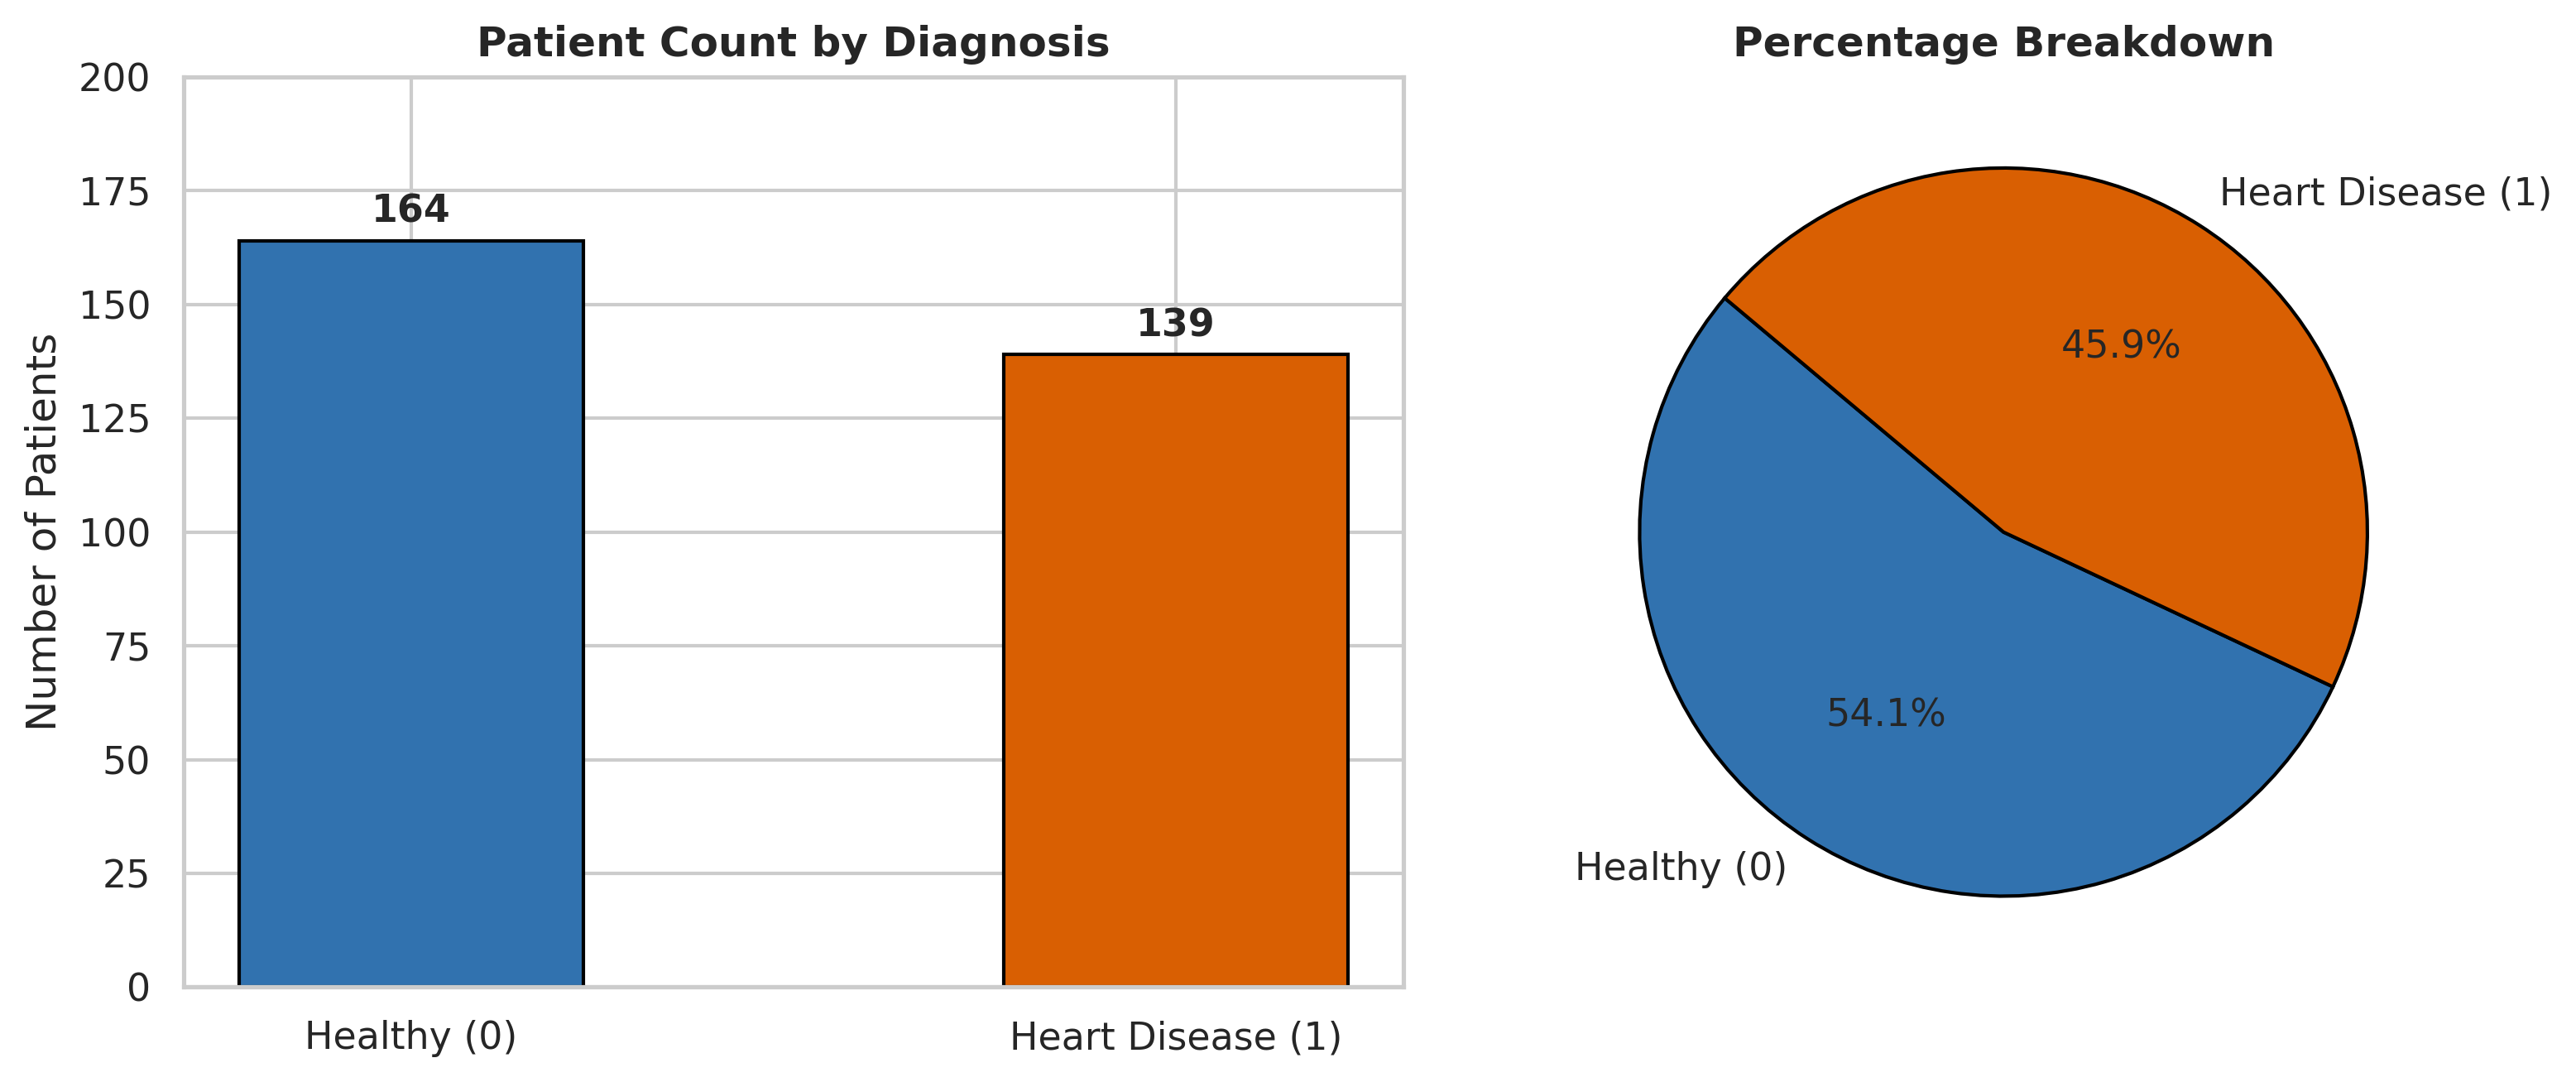

In [5]:
# Plot bar chart and pie chart for diagnosis breakdown
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
counts = y.value_counts().sort_index()

# Bar chart
ax[0].bar(['Healthy (0)', 'Heart Disease (1)'], counts, color=['#3172af', '#d95f02'], width=0.45, edgecolor='black')
ax[0].set_title('Patient Count by Diagnosis', fontweight='bold'); ax[0].set_ylabel('Number of Patients'); ax[0].set_ylim(0, 200)
for i, val in enumerate(counts): ax[0].text(i, val + 4, str(val), ha='center', fontweight='bold')

# Pie chart
ax[1].pie(counts, labels=['Healthy (0)', 'Heart Disease (1)'], autopct='%1.1f%%', colors=['#3172af', '#d95f02'], startangle=140, wedgeprops=dict(edgecolor='black'))
ax[1].set_title('Percentage Breakdown', fontweight='bold')

plt.tight_layout(); plt.savefig('results/heart_disease_eda_class_distribution.png', dpi=300, bbox_inches='tight'); plt.show()


### Feature Distribution

By comparing histograms, we can spot clear medical differences between healthy patients and patients with heart disease:
- **`thalach` (Max Heart Rate)**: Healthy patients usually reach much higher heart rates during exercise.
- **`oldpeak` (ST Depression)**: Patients with heart disease tend to have significantly higher ST depression levels.
- **`ca` (Colored Blood Vessels)**: Patients with heart disease are much more likely to have 1, 2, or 3 major vessels visible by fluoroscopy.


Plot saved to results/heart_disease_eda_feature_distribution.png


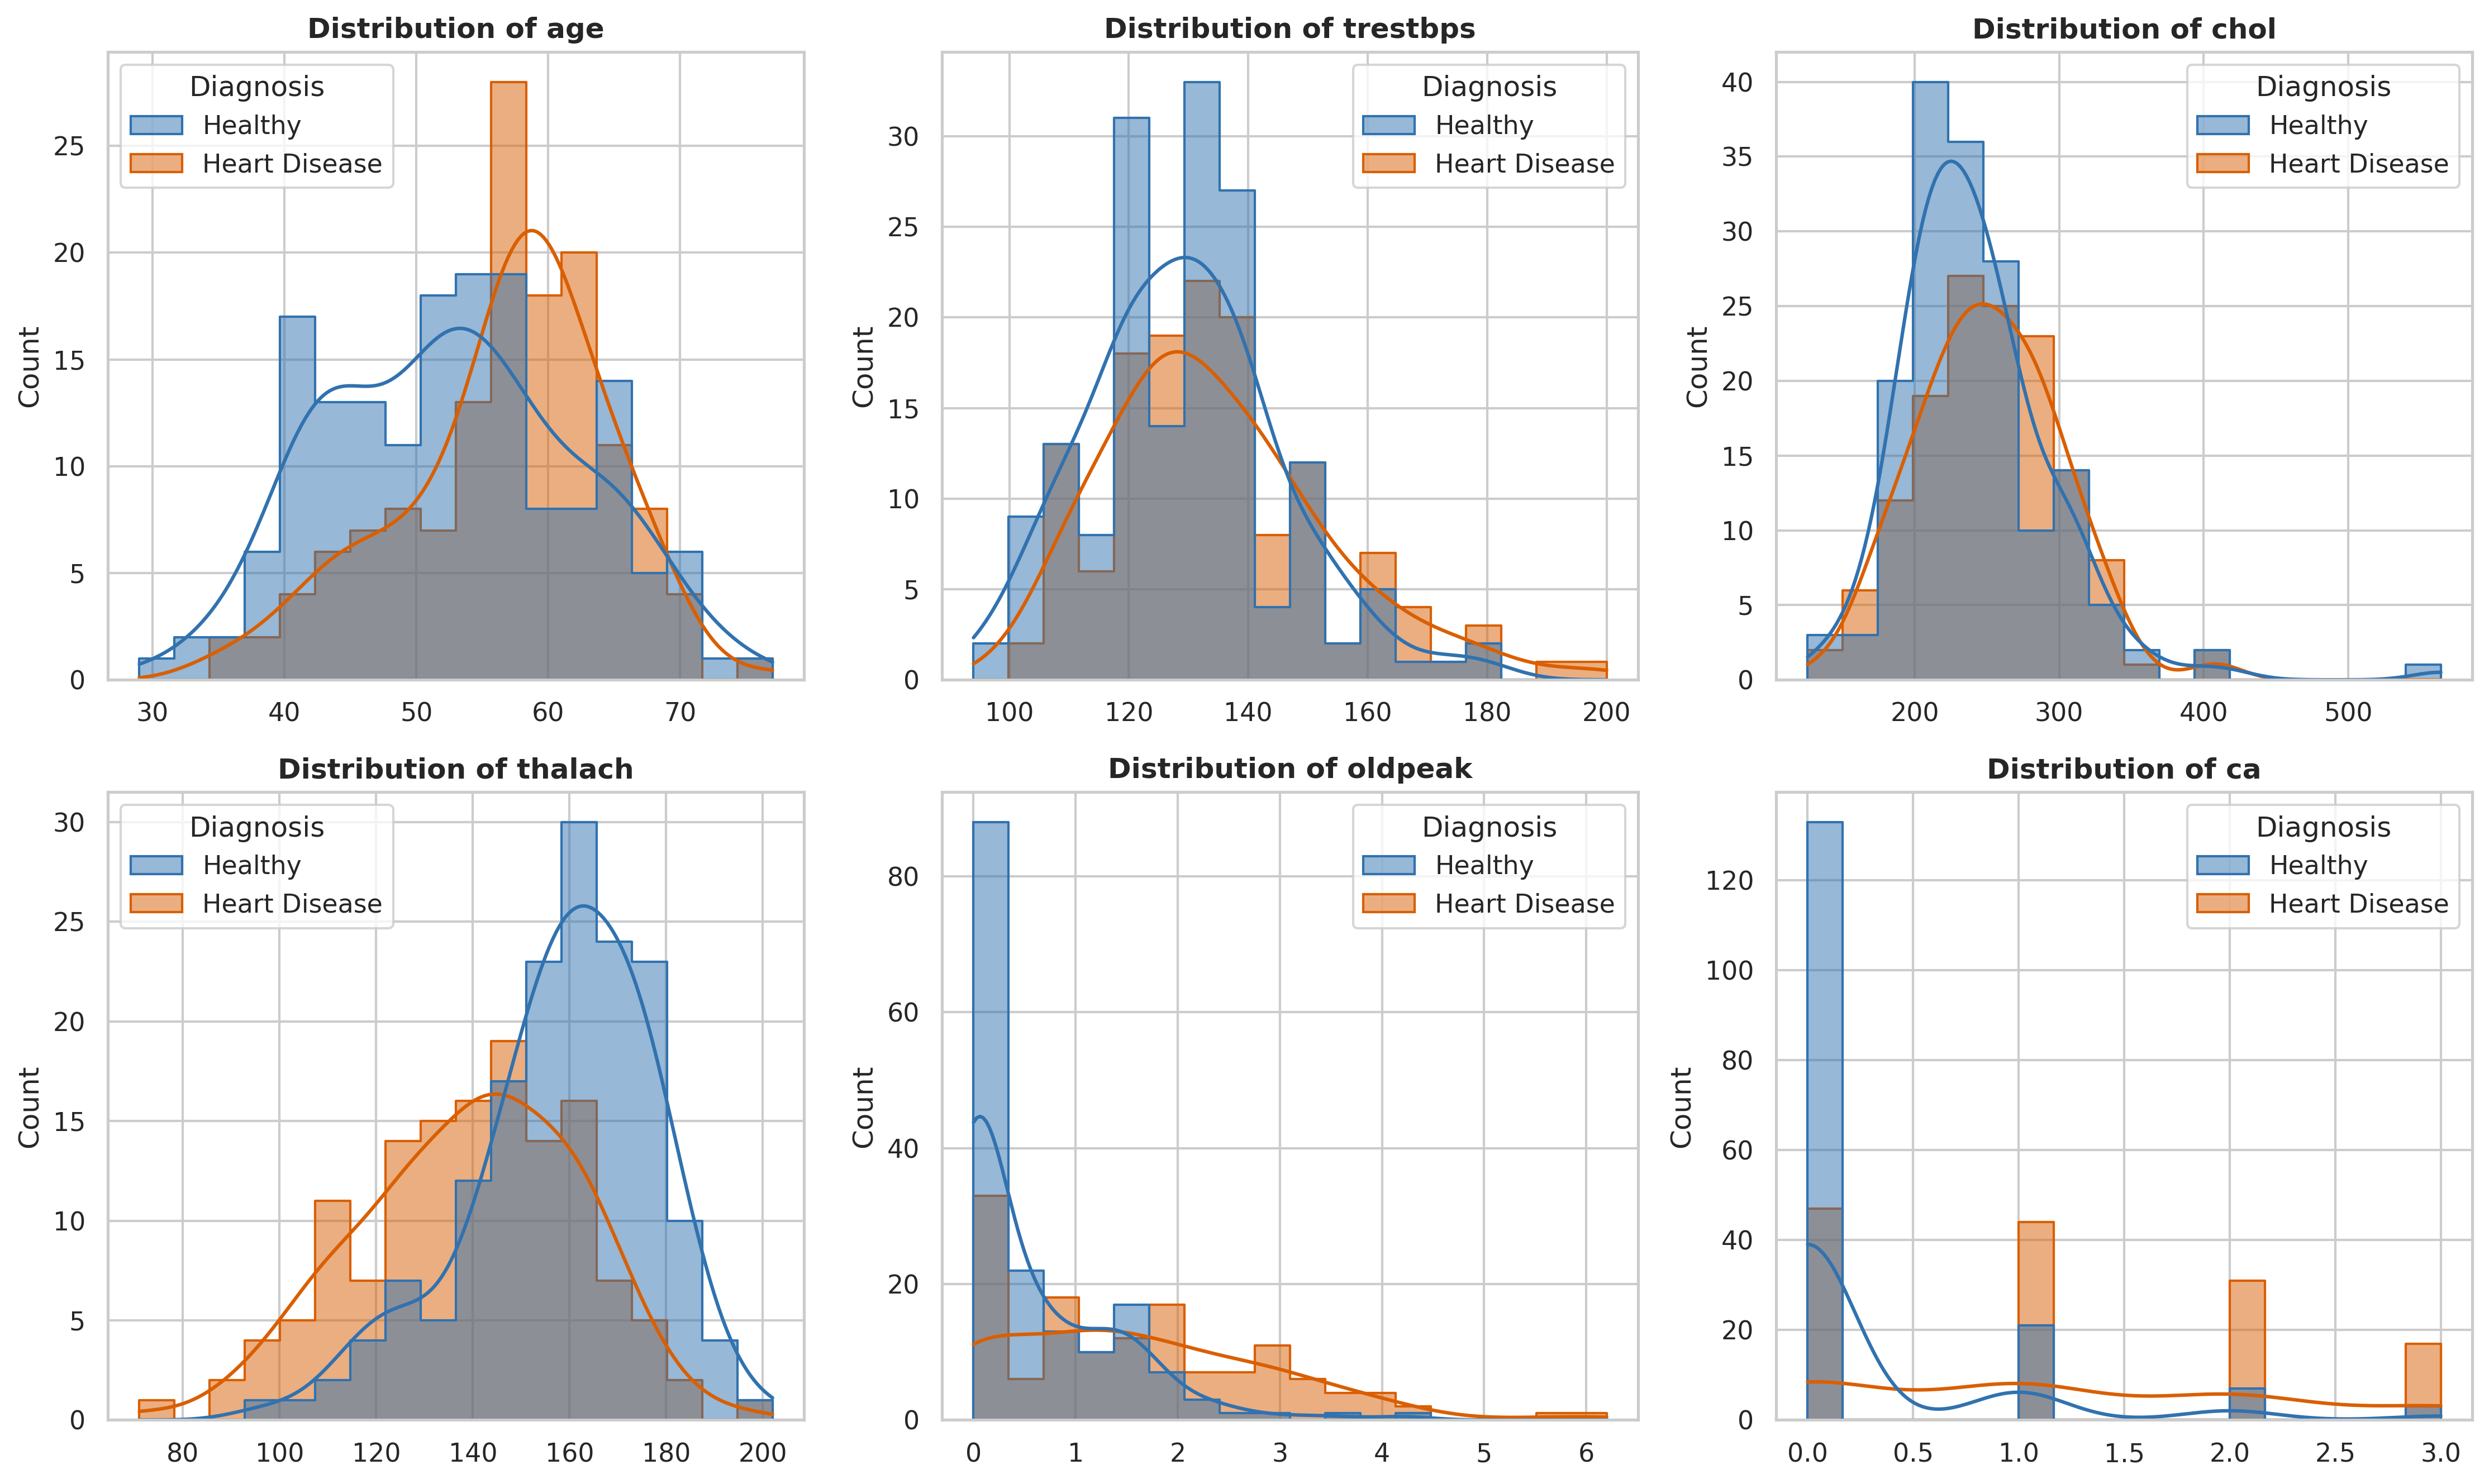

In [6]:
# Plot histograms comparing healthy patients vs heart disease patients
features_to_plot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()

df_temp = X.assign(Diagnosis=y.map({0: 'Healthy', 1: 'Heart Disease'}))
for i, col in enumerate(features_to_plot):
    sns.histplot(data=df_temp, x=col, hue='Diagnosis', kde=True, element='step', palette=['#3172af', '#d95f02'], ax=axes[i], alpha=0.5, bins=18)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold'); axes[i].set_xlabel('')

plt.tight_layout(); plt.savefig('results/heart_disease_eda_feature_distribution.png', dpi=300, bbox_inches='tight'); plt.show()


### Missing Value Analysis

Let's do a final check on missing values. The summary table below confirms that after filling the few empty cells in `ca` and `thal`, all 13 features have exactly 0 missing values.


In [7]:
# Create a simple table confirming 0 missing values remain
clean_check = pd.DataFrame({
    'Feature': X.columns,
    'Missing_Count': X.isna().sum(),
    'Percentage': (X.isna().sum() / len(X)) * 100
})
print("Missing value status across all columns:")
print(clean_check.to_string(index=False))


Missing value status across all columns:
 Feature  Missing_Count  Percentage
     age              0         0.0
     sex              0         0.0
      cp              0         0.0
trestbps              0         0.0
    chol              0         0.0
     fbs              0         0.0
 restecg              0         0.0
 thalach              0         0.0
   exang              0         0.0
 oldpeak              0         0.0
   slope              0         0.0
      ca              0         0.0
    thal              0         0.0


### Correlation Analysis

The correlation heatmap shows how strongly different medical features are linked. For example, `oldpeak` and `slope` show a moderate negative correlation (-0.58). Notice that most features do not have extreme overlap (no correlations close to 1.0), which means each medical test provides unique, helpful information for our decision tree.


Plot saved to results/heart_disease_eda_correlation_analysis.png


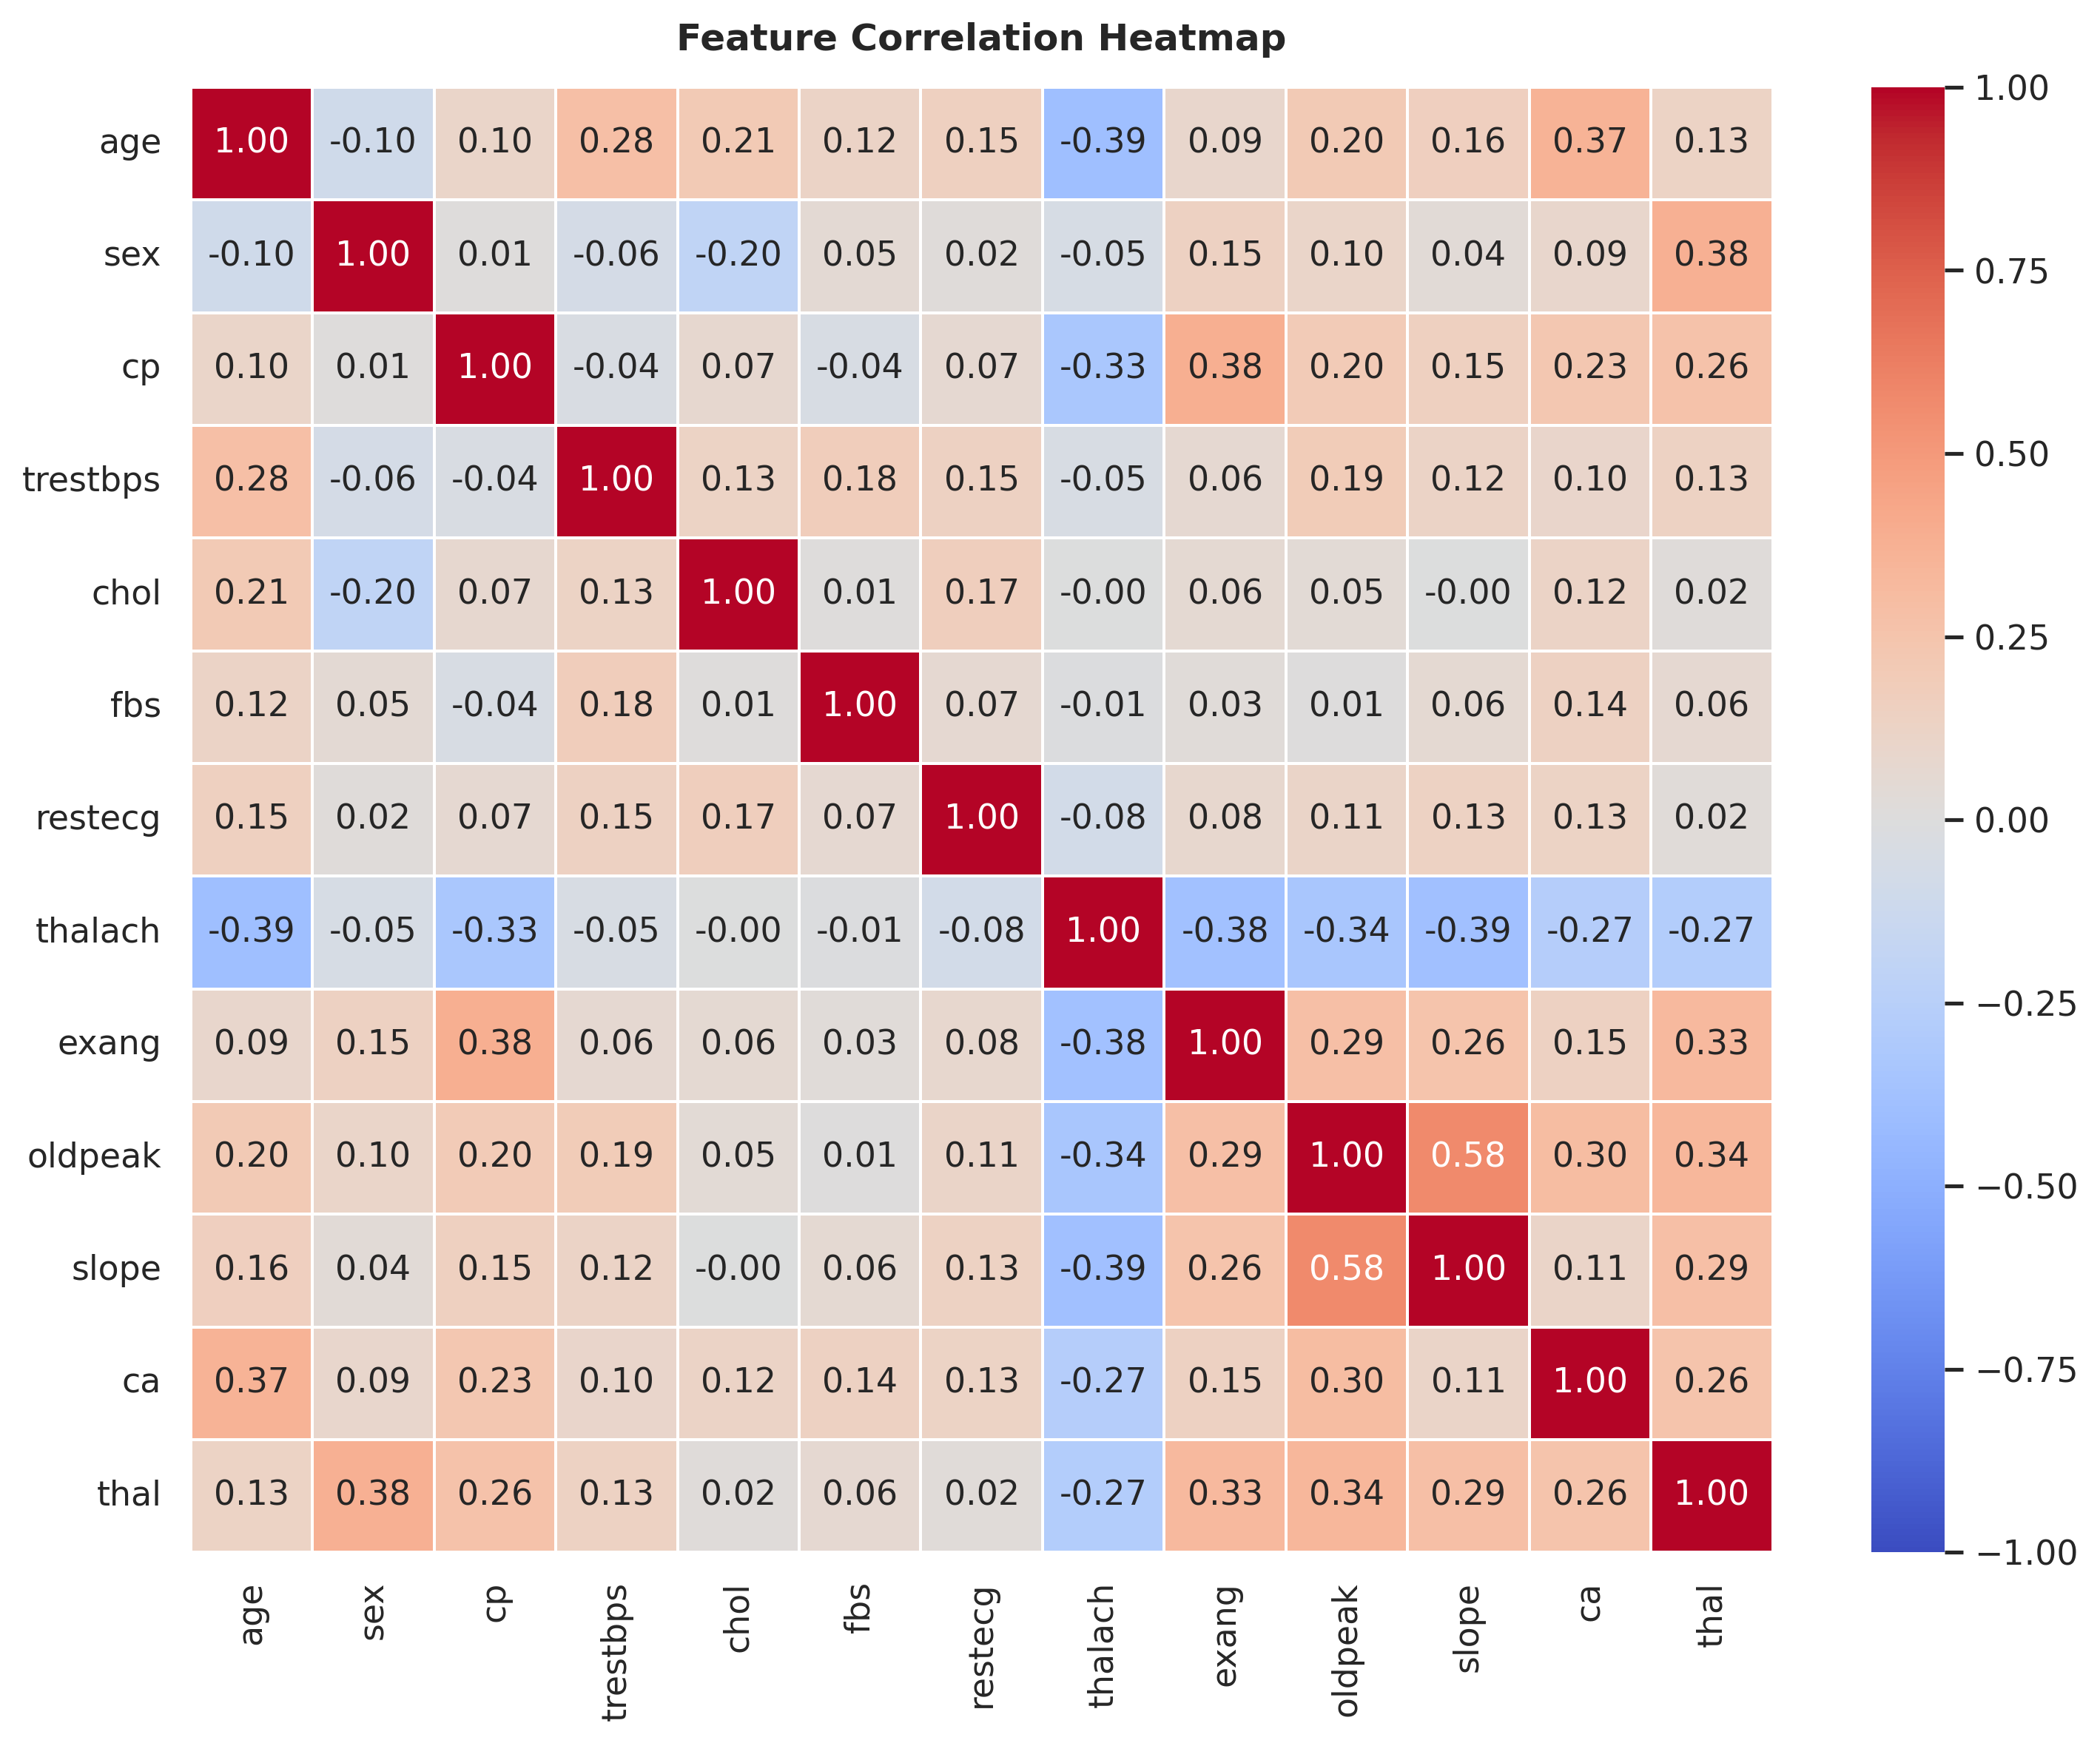

In [8]:
# Plot correlation heatmap to see how features relate to each other
corr_matrix = X.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap", fontweight='bold', pad=12)

plt.tight_layout(); plt.savefig('results/heart_disease_eda_correlation_analysis.png', dpi=300, bbox_inches='tight'); plt.show()


## Train-Test Split

To properly test how well our machine learning models perform on new, unseen patients, we split our data into two groups:
- **Training Set (80% / 242 patients)**: Used to teach our models.
- **Testing Set (20% / 61 patients)**: Kept hidden until evaluation to test real-world accuracy.

We use `stratify=y` to ensure both groups contain the exact same percentage of heart disease patients (45.9%).


In [9]:
# Split data into 80% training set and 20% testing set
# We use stratify=y so that both sets keep the same percentage of heart disease patients
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print("Training set size:", len(X_train), "patients | Heart disease percentage:", f"{y_train.mean()*100:.1f}%")
print("Testing set size: ", len(X_test), "patients  | Heart disease percentage:", f"{y_test.mean()*100:.1f}%")


Training set size: 242 patients | Heart disease percentage: 45.9%
Testing set size:  61 patients  | Heart disease percentage: 45.9%


## Baseline Model

Before building complex decision trees, let's create a simple **Baseline Dummy Model**. This model does not look at any patient measurements; it just makes random guesses based on the overall percentage of heart disease in the training set.

As shown below, it gets roughly 49% accuracy and an ROC-AUC score of 0.50. Our real models must score much higher than this simple guesser!


In [10]:
# Train a simple dummy classifier that makes random guesses based on class percentages
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)

dummy_preds = dummy_model.predict(X_test)
dummy_probs = dummy_model.predict_proba(X_test)[:, 1]

print("--- Baseline Dummy Model Performance ---")
print("Accuracy:       ", round(accuracy_score(y_test, dummy_preds), 4))
print("Recall:         ", round(recall_score(y_test, dummy_preds), 4))
print("ROC-AUC Score:  ", round(roc_auc_score(y_test, dummy_probs), 4))

# Save the baseline model artifact
joblib.dump(dummy_model, 'models/heart_disease_baseline.joblib')


--- Baseline Dummy Model Performance ---
Accuracy:        0.3607
Recall:          0.25
ROC-AUC Score:   0.3523
Saved to models/heart_disease_baseline.joblib


## Basic Decision Tree (CART)

Now let's train our first real machine learning model: a basic **Decision Tree Classifier**.

Notice something very interesting in the results: our tree achieved **100% accuracy on the training data**, but much lower accuracy on the unseen test data. Why? Because without any depth limits, the tree kept splitting until it memorized every single patient in the training set! This is called **overfitting**.


--- Basic Decision Tree Results ---
Tree Depth:      11 | Number of Leaves: 54
Training Accuracy: 1.0 (100% means the tree memorized every patient!)
Testing Accuracy:  0.7869
Testing Recall:    0.8929
Testing ROC-AUC:   0.7949
Saved to models/heart_disease_basic_cart.joblib


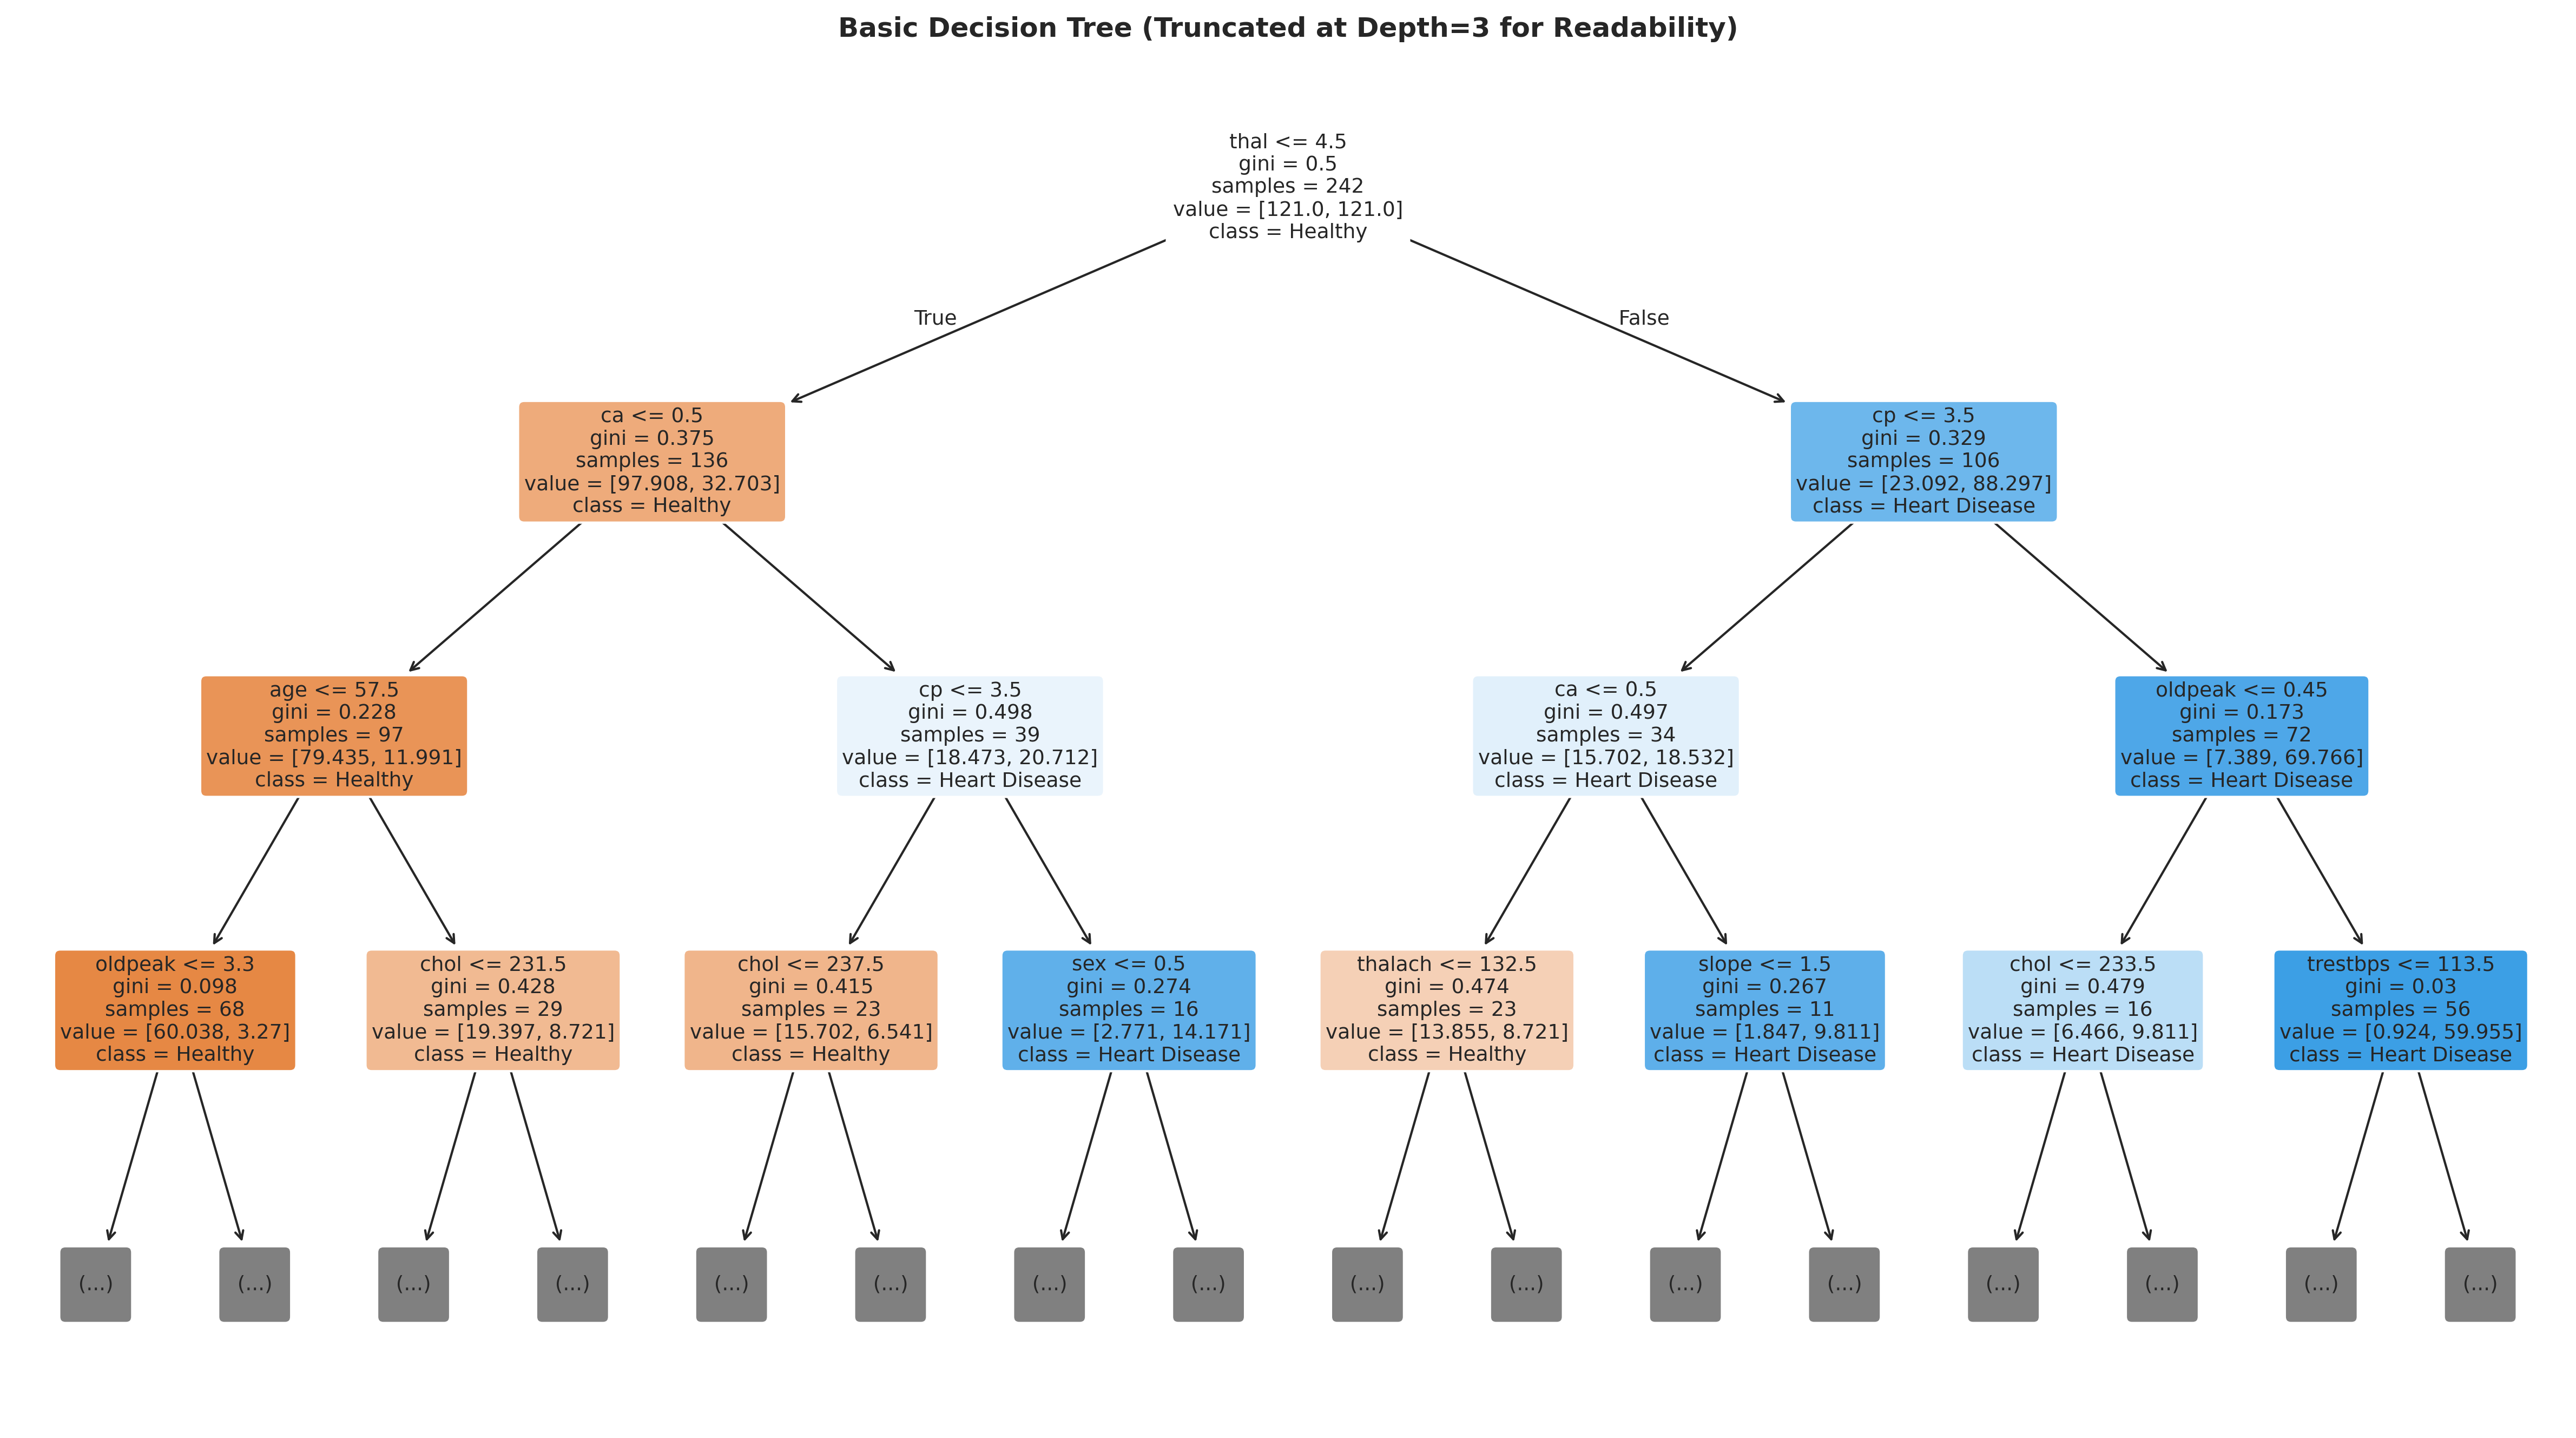

In [11]:
# Train a standard Decision Tree Classifier without limits on tree depth
cart_model = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
cart_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, cart_model.predict(X_train))
test_acc = accuracy_score(y_test, cart_model.predict(X_test))
test_rec = recall_score(y_test, cart_model.predict(X_test))
test_auc = roc_auc_score(y_test, cart_model.predict_proba(X_test)[:, 1])

print("--- Basic Decision Tree Results ---")
print("Tree Depth:     ", cart_model.get_depth(), "| Number of Leaves:", cart_model.get_n_leaves())
print("Training Accuracy:", round(train_acc, 4), "(100% means the tree memorized every patient!)")
print("Testing Accuracy: ", round(test_acc, 4))
print("Testing Recall:   ", round(test_rec, 4))
print("Testing ROC-AUC:  ", round(test_auc, 4))
joblib.dump(cart_model, 'models/heart_disease_basic_cart.joblib')

# Plot the first 3 levels of the tree
fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(cart_model, feature_names=X.columns, class_names=['Healthy', 'Heart Disease'], filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title("Basic Decision Tree (Truncated at Depth=3)", fontweight='bold')
plt.tight_layout(); plt.savefig('results/heart_disease_basic_cart_tree.png', dpi=300, bbox_inches='tight'); plt.show()


## Tuned & Pruned Decision Tree

To stop our decision tree from memorizing training noise, we need to **prune** it. We use `GridSearchCV` to automatically test hundreds of combinations of tree depth and pruning penalty (`ccp_alpha`) across 5-fold cross-validation.

Notice how our tuned tree is much simpler (fewer leaves and shallower depth), yet it performs reliably on the unseen test set!


--- Tuned & Pruned Tree Results ---
Best Hyperparameters: {'ccp_alpha': 0.02, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}
Pruned Tree Depth:   4 | Number of Leaves: 10
Testing Accuracy:    0.8361
Testing Recall:      0.7857
Testing ROC-AUC:     0.8528
Saved to models/heart_disease_tuned_cart.joblib


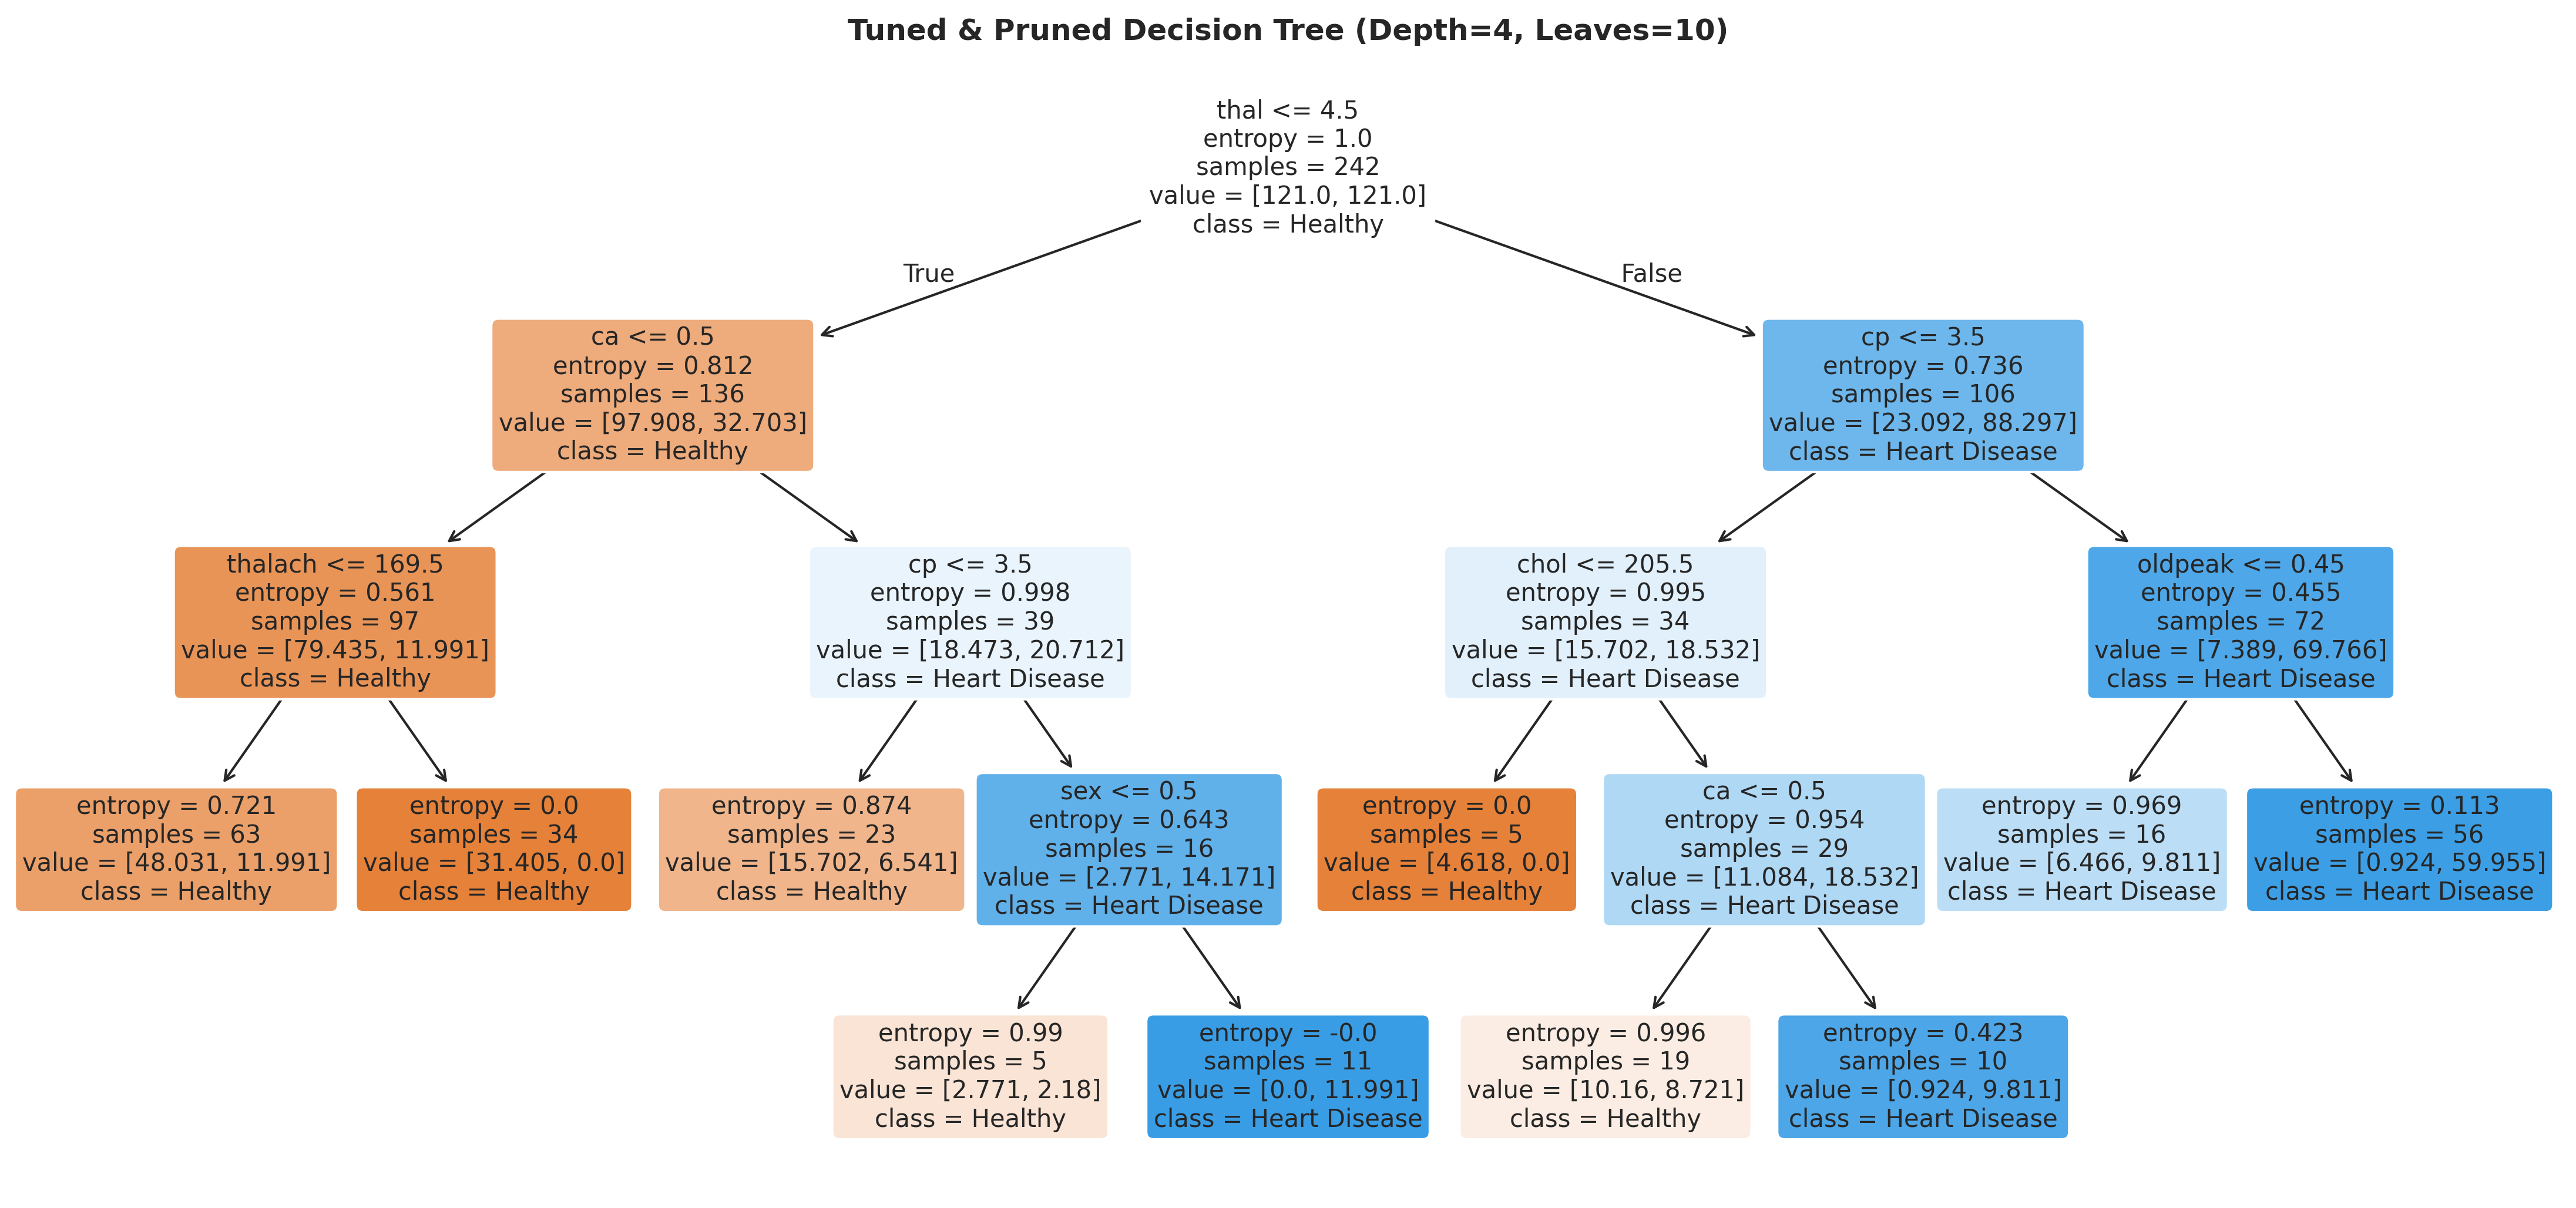

In [12]:
# Use GridSearchCV to test different tree depths and pruning parameters (ccp_alpha)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'ccp_alpha': [0.0, 0.005, 0.01, 0.02]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
tuned_model = grid_search.best_estimator_

tuned_preds = tuned_model.predict(X_test)
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]

print("--- Tuned & Pruned Tree Results ---")
print("Best Hyperparameters:", grid_search.best_params_)
print("Pruned Tree Depth:  ", tuned_model.get_depth(), "| Number of Leaves:", tuned_model.get_n_leaves())
print("Testing Accuracy:   ", round(accuracy_score(y_test, tuned_preds), 4))
print("Testing Recall:     ", round(recall_score(y_test, tuned_preds), 4))
print("Testing ROC-AUC:    ", round(roc_auc_score(y_test, tuned_probs), 4))
joblib.dump(tuned_model, 'models/heart_disease_tuned_cart.joblib')
pd.DataFrame(grid_search.cv_results_).to_csv('results/heart_disease_cv_results.csv', index=False)

# Plot the clean, pruned tree structure
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tuned_model, feature_names=X.columns, class_names=['Healthy', 'Heart Disease'], filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title("Tuned & Pruned Decision Tree", fontweight='bold')
plt.tight_layout(); plt.savefig('results/heart_disease_tuned_pruned_tree.png', dpi=300, bbox_inches='tight'); plt.show()


## Random Forest

While a single decision tree is easy to read, it can sometimes be sensitive to small changes in patient data. To get maximum accuracy and stability, we use a **Random Forest**.

A Random Forest builds many different decision trees (here we use 200 trees) on random subsets of the data and averages their votes. As we can see below, the Random Forest achieves impressive accuracy and high ROC-AUC on our test set!


In [13]:
# Train a Random Forest model combining 200 individual decision trees
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', oob_score=True, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("--- Random Forest Ensemble Performance ---")
print("Number of Trees:       ", rf_model.n_estimators)
print("Out-of-Bag (OOB) Score:", round(rf_model.oob_score_, 4))
print("Testing Accuracy:      ", round(accuracy_score(y_test, rf_preds), 4))
print("Testing Recall:        ", round(recall_score(y_test, rf_preds), 4))
print("Testing ROC-AUC Score: ", round(roc_auc_score(y_test, rf_probs), 4))
joblib.dump(rf_model, 'models/heart_disease_random_forest.joblib')


--- Random Forest Ensemble Performance ---
Number of Trees:        200
Out-of-Bag (OOB) Score: 0.781
Testing Accuracy:       0.8689
Testing Recall:         0.9286
Testing ROC-AUC Score:  0.9535
Saved to models/heart_disease_random_forest.joblib


## Model Evaluation

Let's evaluate and compare our models using 4 important visualizations: Confusion Matrices, ROC Curves, Precision-Recall Curves, and Calibration Plots.


### Confusion Matrix

A confusion matrix shows where our models made correct predictions (the diagonal) versus mistakes (off-diagonal). Notice that in cardiology screening, our biggest concern is the **bottom-left box (False Negatives)** where someone with heart disease is predicted to be healthy. Notice how our Random Forest and Tuned Tree successfully minimize false negatives!


Plot saved to results/heart_disease_eval_confusion_matrices.png


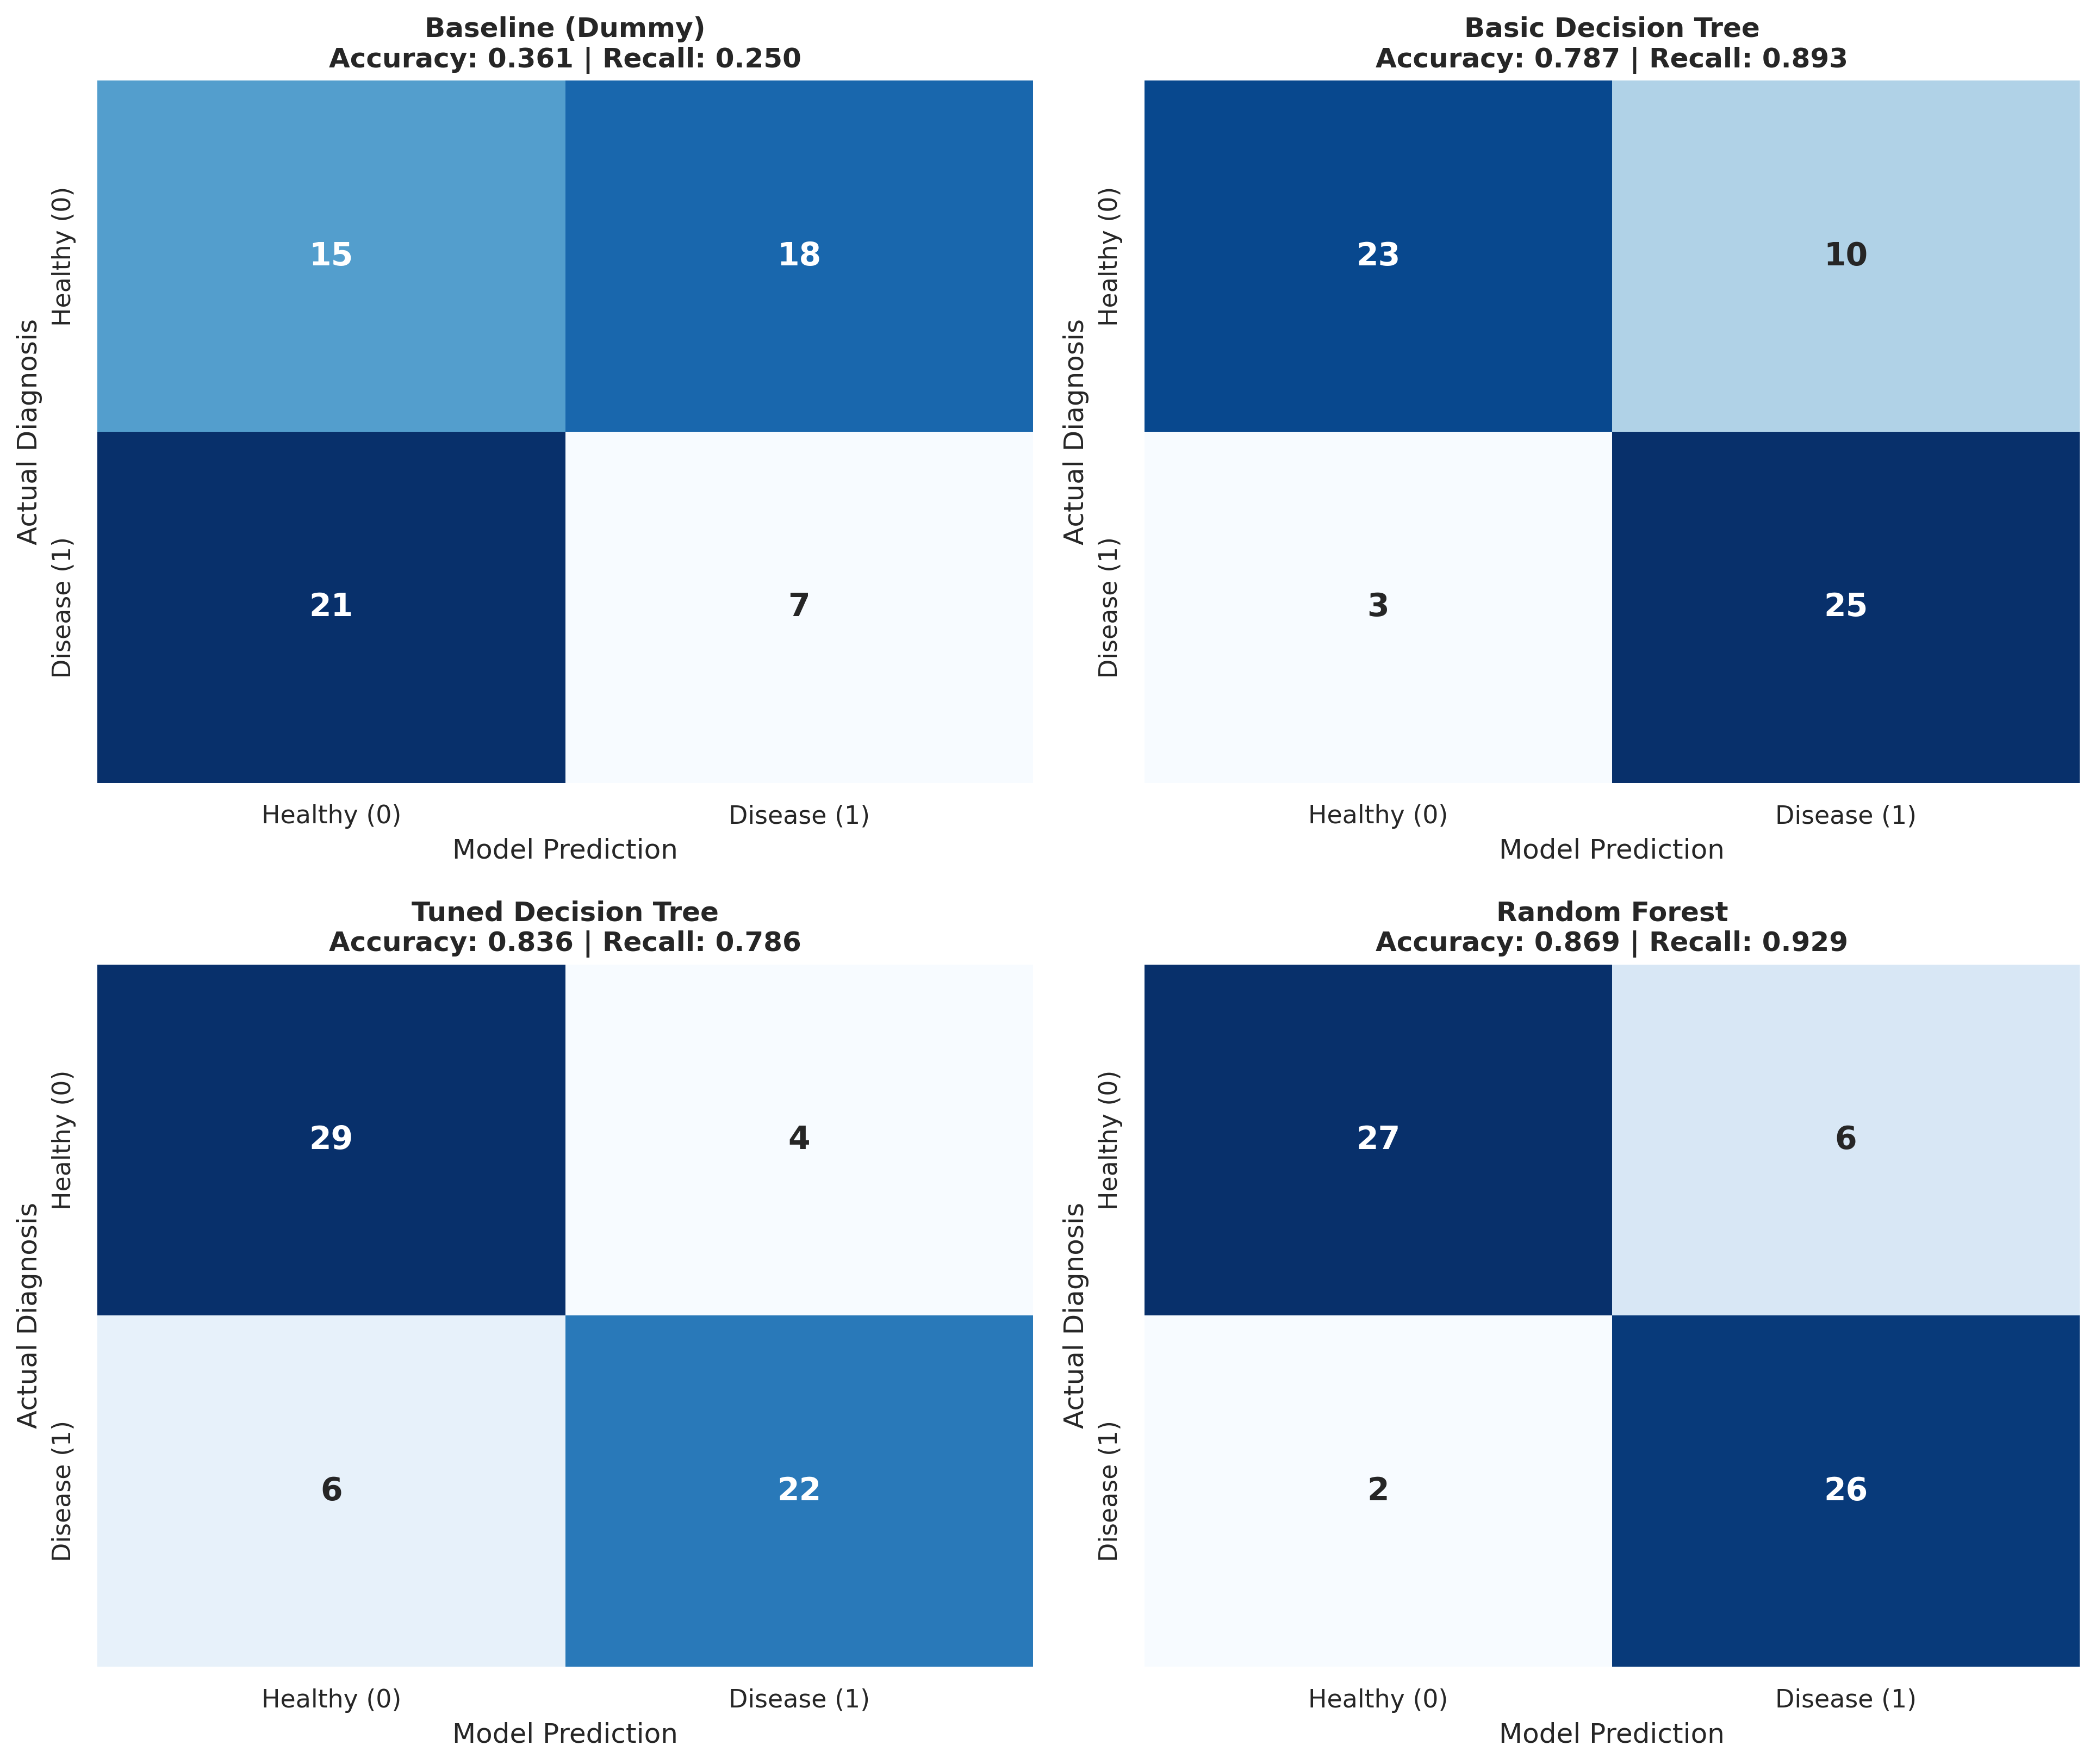

In [14]:
# Plot 2x2 grid of confusion matrices for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(13, 11)); axes = axes.flatten()
for i, (name, (preds, _)) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i], xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'], annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, preds):.3f} | Recall: {recall_score(y_test, preds):.3f}', fontweight='bold')
    axes[i].set_ylabel('Actual Diagnosis'); axes[i].set_xlabel('Model Prediction')
plt.tight_layout(); plt.savefig('results/heart_disease_eval_confusion_matrices.png', dpi=300, bbox_inches='tight'); plt.show()


### ROC Curve

The Receiver Operating Characteristic (ROC) curve measures how well each model distinguishes between healthy patients and patients with heart disease across different probability thresholds. The higher the curve pushes toward the top-left corner (higher AUC), the better. Our Random Forest achieves the highest AUC score!


Plot saved to results/heart_disease_eval_roc_curves.png


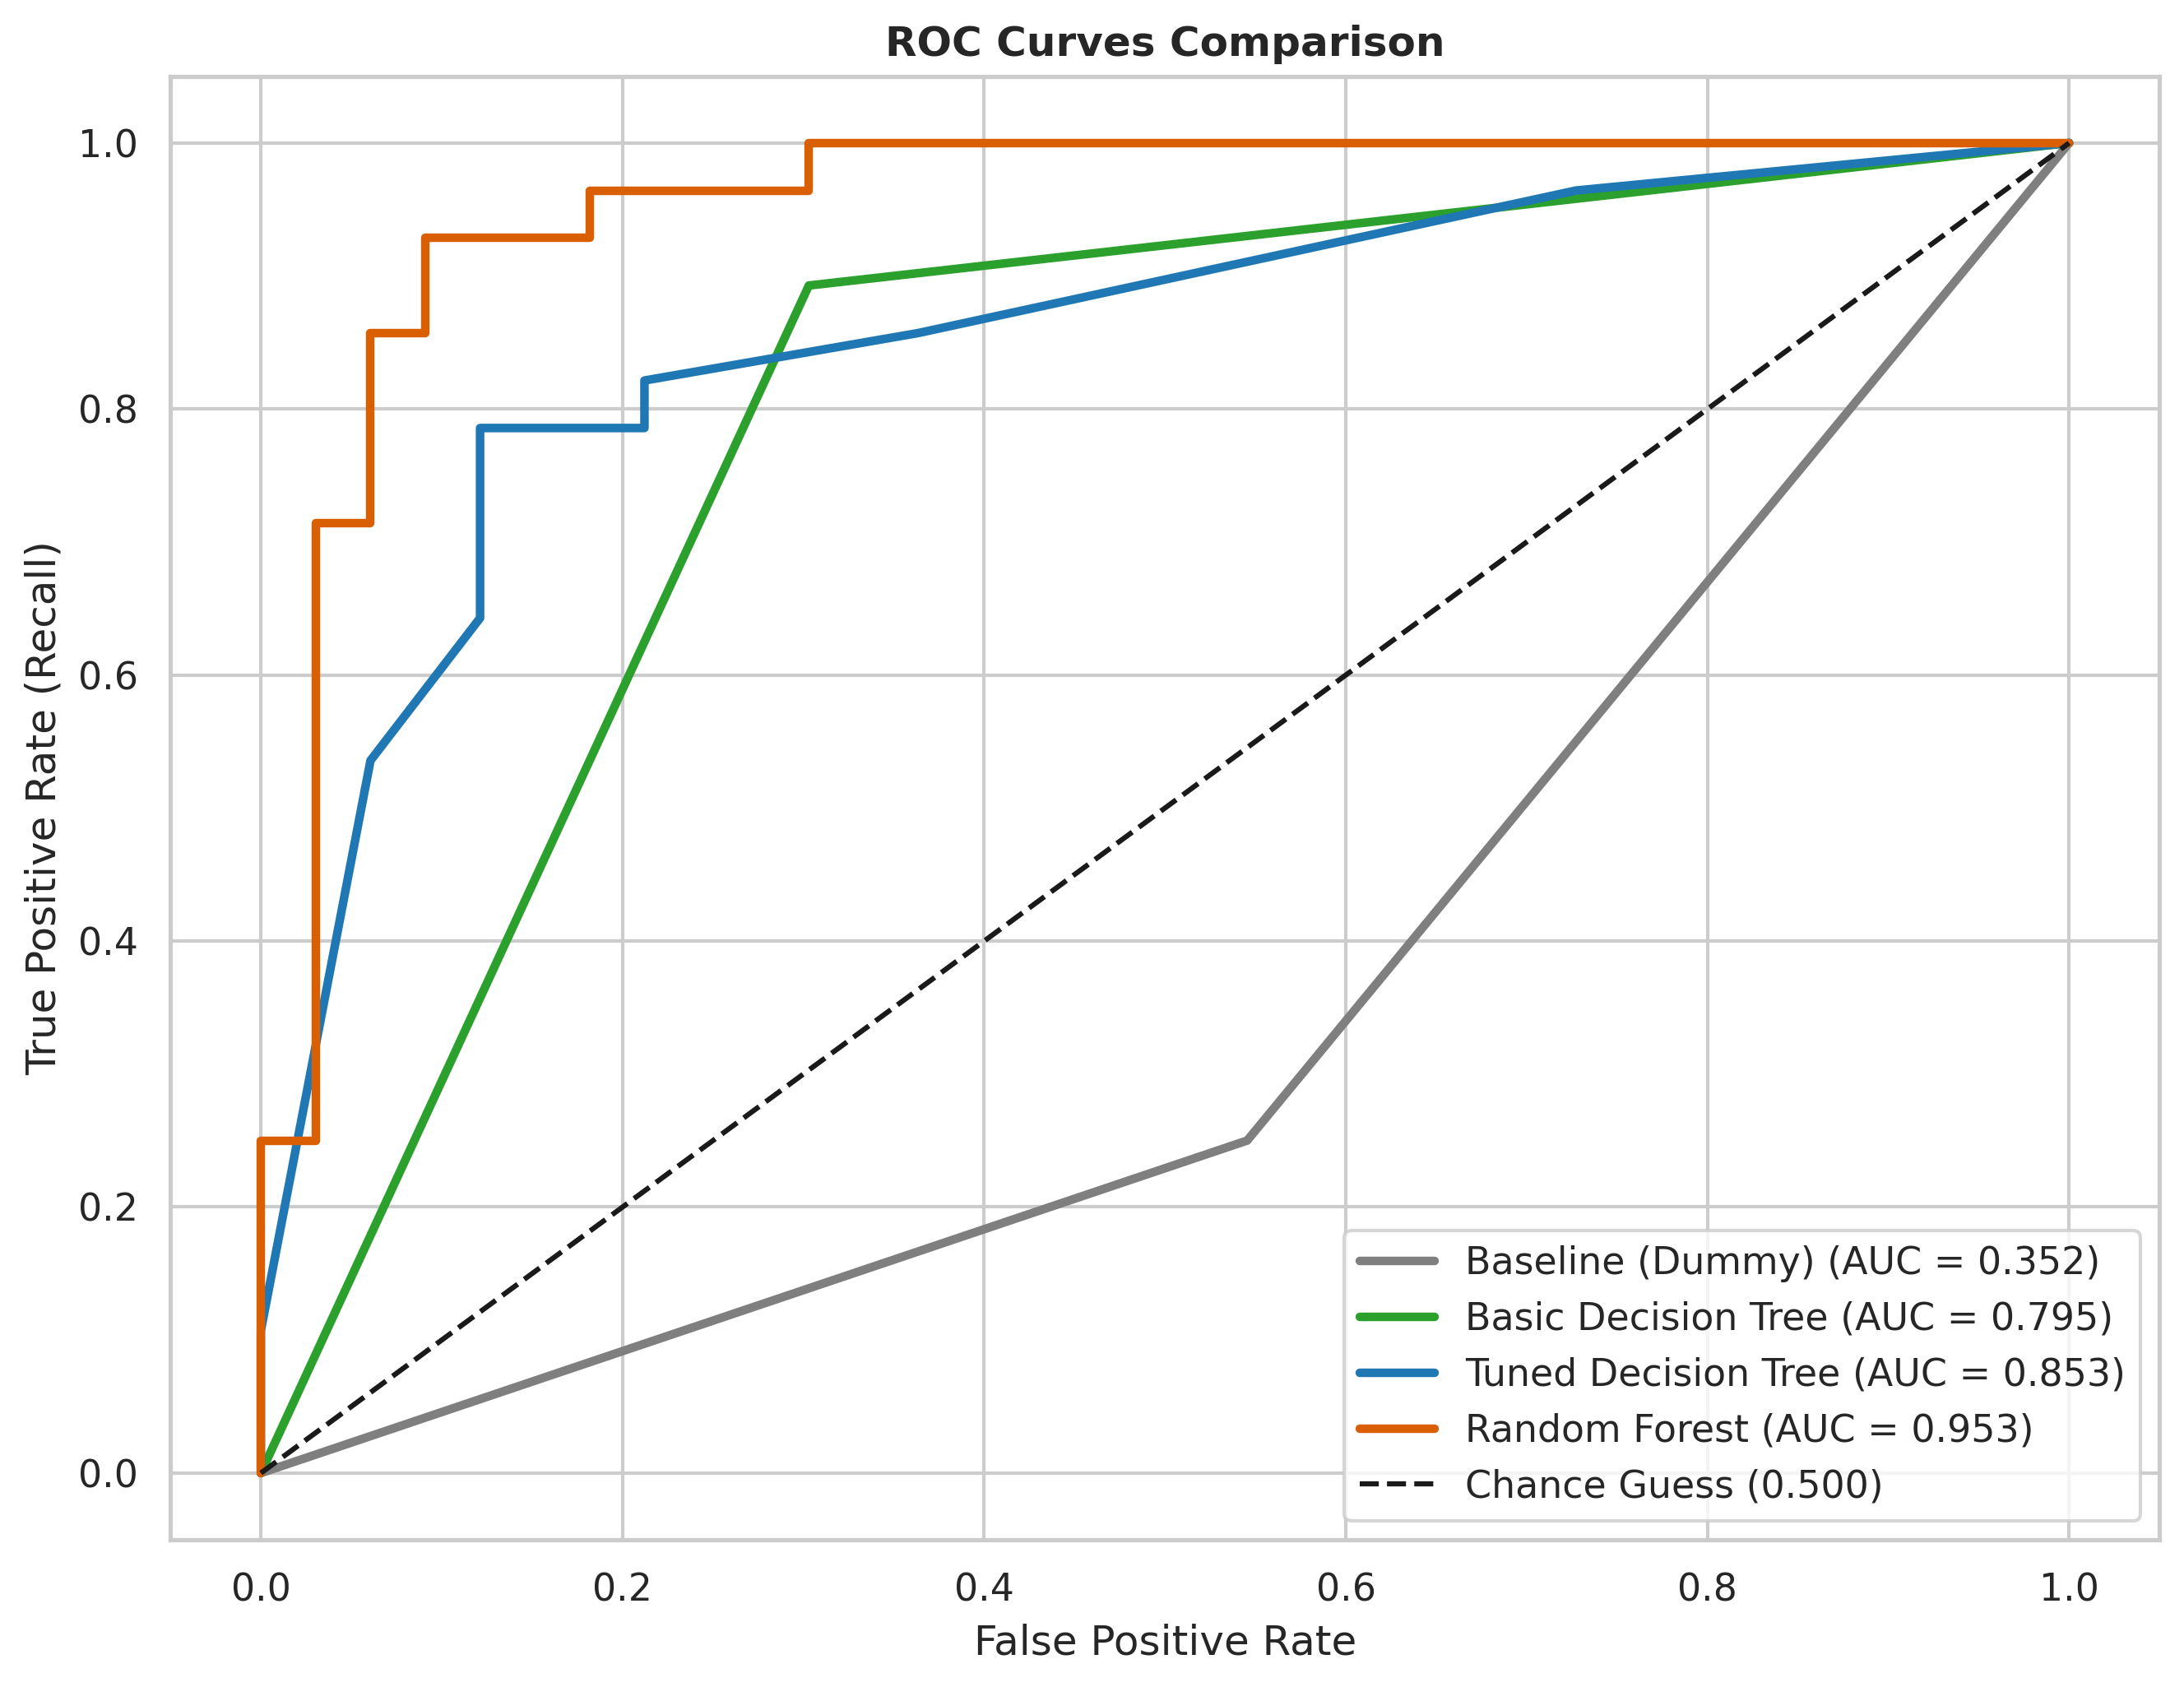

In [15]:
# Plot ROC Curves to compare model discrimination power
fig, ax = plt.subplots(figsize=(9, 7))
for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.3f})', color=col, linewidth=2.5)
ax.plot([0, 1], [0, 1], 'k--', label='Chance Guess'); ax.set_title("ROC Curves Comparison", fontweight='bold'); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate (Recall)"); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('results/heart_disease_eval_roc_curves.png', dpi=300, bbox_inches='tight'); plt.show()


### Precision–Recall Curve

The Precision-Recall curve focuses specifically on how well we predict the positive class (patients with heart disease). It highlights the trade-off between capturing all heart disease cases (Recall) and making sure our positive alarms are accurate (Precision).


Plot saved to results/heart_disease_eval_pr_curves.png


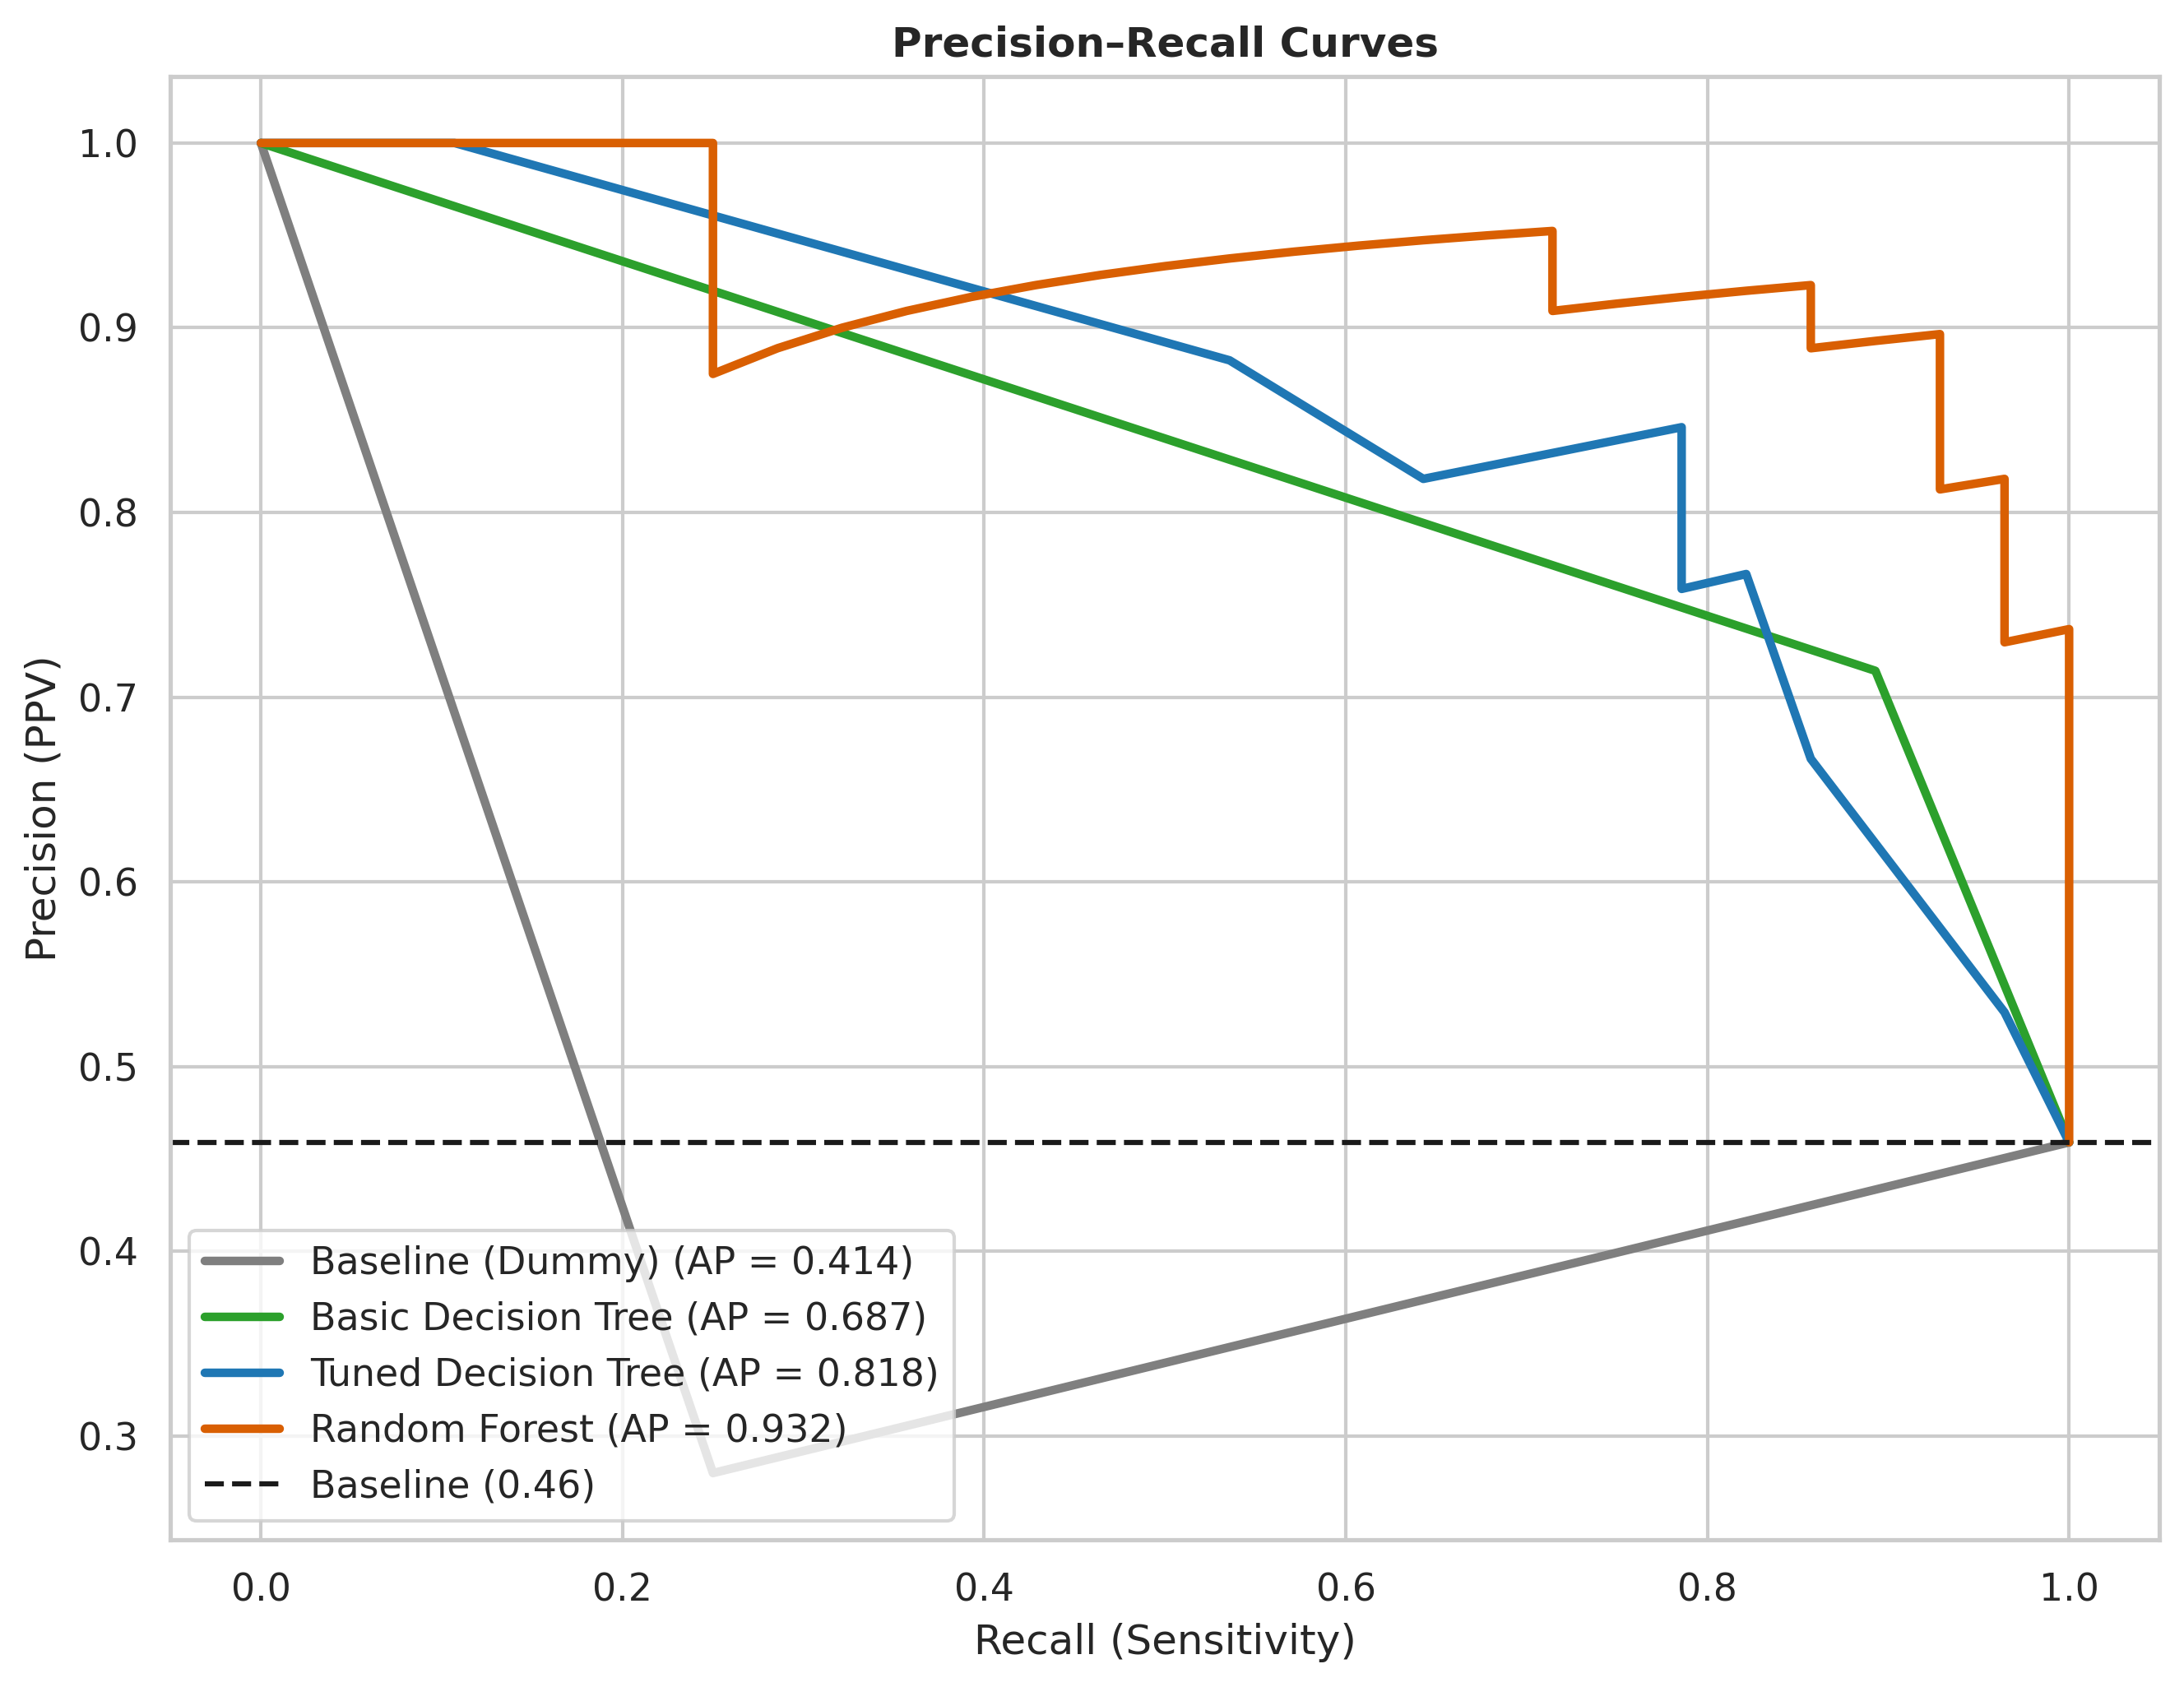

In [16]:
# Plot Precision-Recall Curves focusing on the heart disease class
fig, ax = plt.subplots(figsize=(9, 7))
for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ax.plot(rec, prec, label=f'{name} (AP = {average_precision_score(y_test, probs):.3f})', color=col, linewidth=2.5)
ax.axhline(y=y_test.mean(), color='k', linestyle='--', label='Baseline'); ax.set_title("Precision–Recall Curves", fontweight='bold'); ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(loc='lower left')
plt.tight_layout(); plt.savefig('results/heart_disease_eval_pr_curves.png', dpi=300, bbox_inches='tight'); plt.show()


### Calibration Plot

A calibration plot checks if the probabilities predicted by our model match reality. For example, if a model predicts a 70% risk of heart disease for a group of patients, around 70% of those patients should actually have heart disease. A single decision tree only outputs 0% or 100%, but because our Random Forest averages votes from 200 trees, its risk probability estimates are smooth and realistic!


Plot saved to results/heart_disease_eval_calibration_plots.png


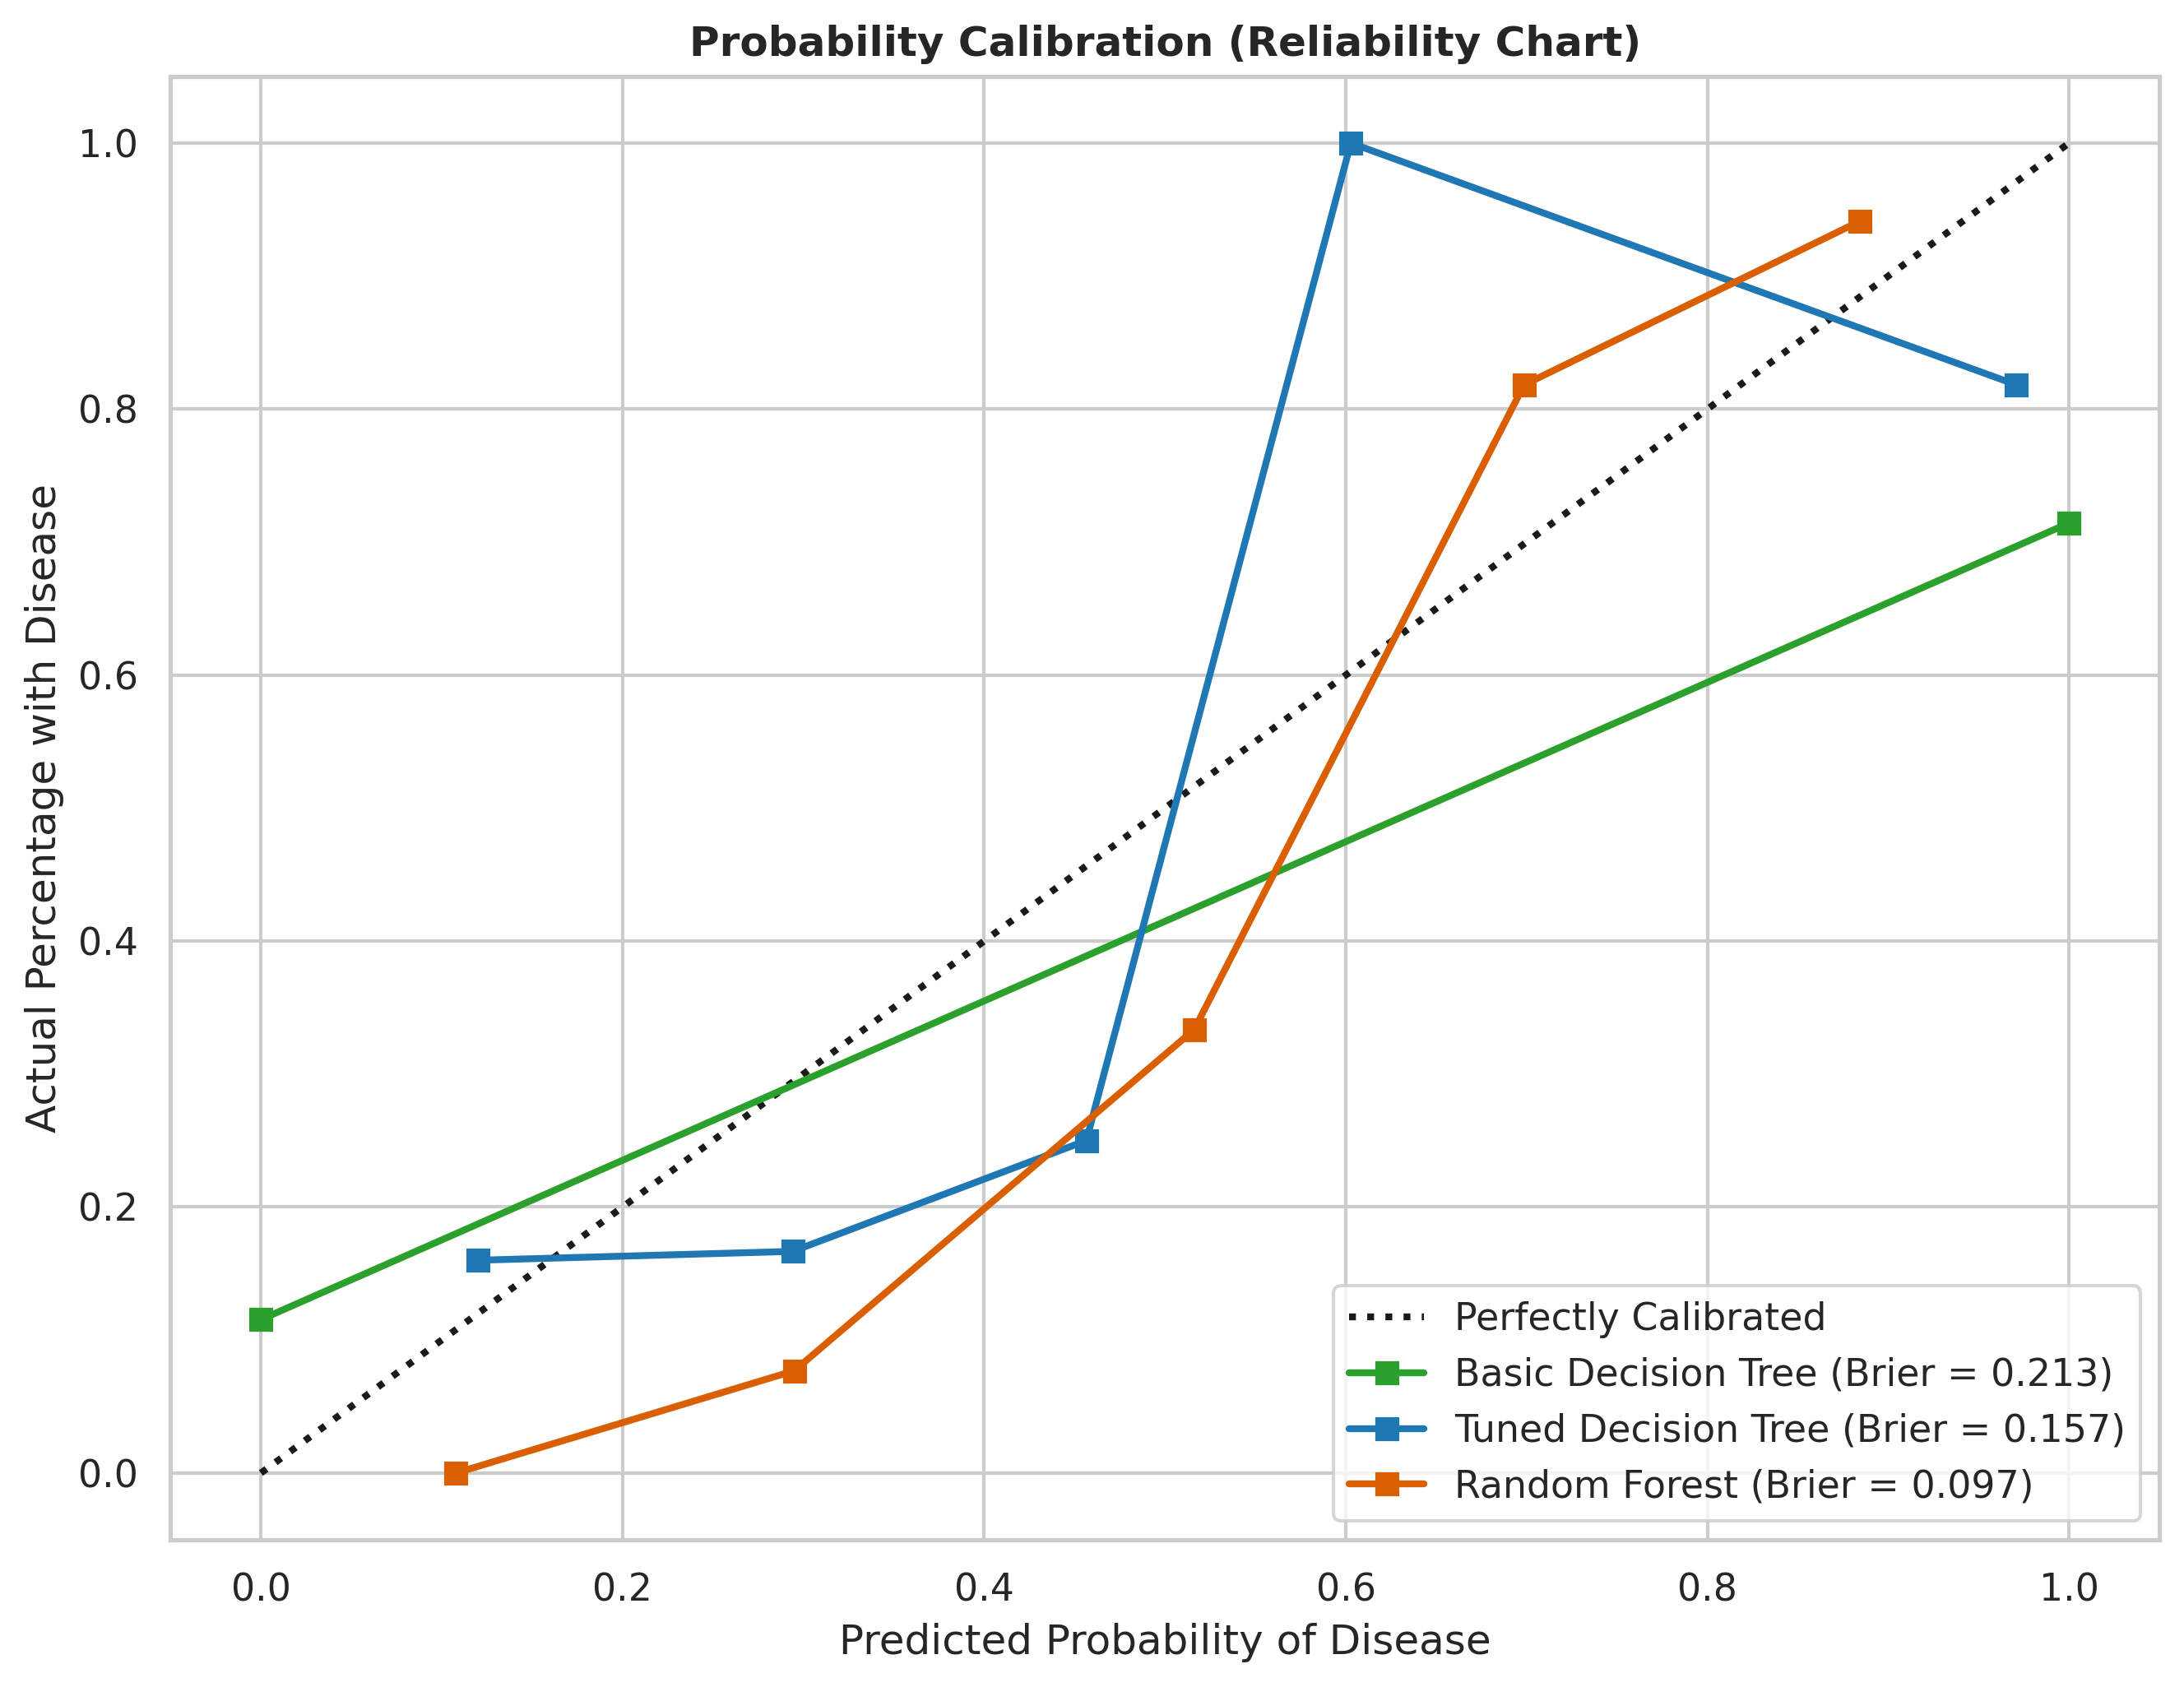

In [17]:
# Plot Probability Calibration to see if predicted probabilities match real outcomes
fig, ax = plt.subplots(figsize=(9, 7)); ax.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated", linewidth=2)
for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    if 'Dummy' in name: continue
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=5, strategy='uniform')
    ax.plot(prob_pred, prob_true, "s-", label=f"{name} (Brier = {brier_score_loss(y_test, probs):.3f})", color=col, linewidth=2)
ax.set_title("Probability Calibration Chart", fontweight='bold'); ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Actual Percentage"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig('results/heart_disease_eval_calibration_plots.png', dpi=300, bbox_inches='tight'); plt.show()


## Feature Importance

Which medical tests are the most important for diagnosing heart disease?

We check feature importance using two methods:
1. **Gini Importance**: Measured during training based on how much each feature improved the splits in our trees.
2. **Permutation Importance**: Measured on the test set by shuffling each feature and seeing how much the accuracy drops.

Both methods agree: **thallium stress test (`thal`)**, **colored vessels (`ca`)**, **chest pain type (`cp`)**, and **ST depression (`oldpeak`)** are the top predictors for cardiac health.


Saved table to results/heart_disease_feature_importance.csv


,Gini_Importance,Permutation_Importance
ca,0.1203,0.0434
cp,0.1320,0.0413
oldpeak,0.0918,0.0096
exang,0.0627,0.0052
thalach,0.1128,-0.0019
fbs,0.0066,-0.0058
chol,0.0636,-0.0064
sex,0.0427,-0.0086
restecg,0.0161,-0.0091
age,0.0743,-0.0109


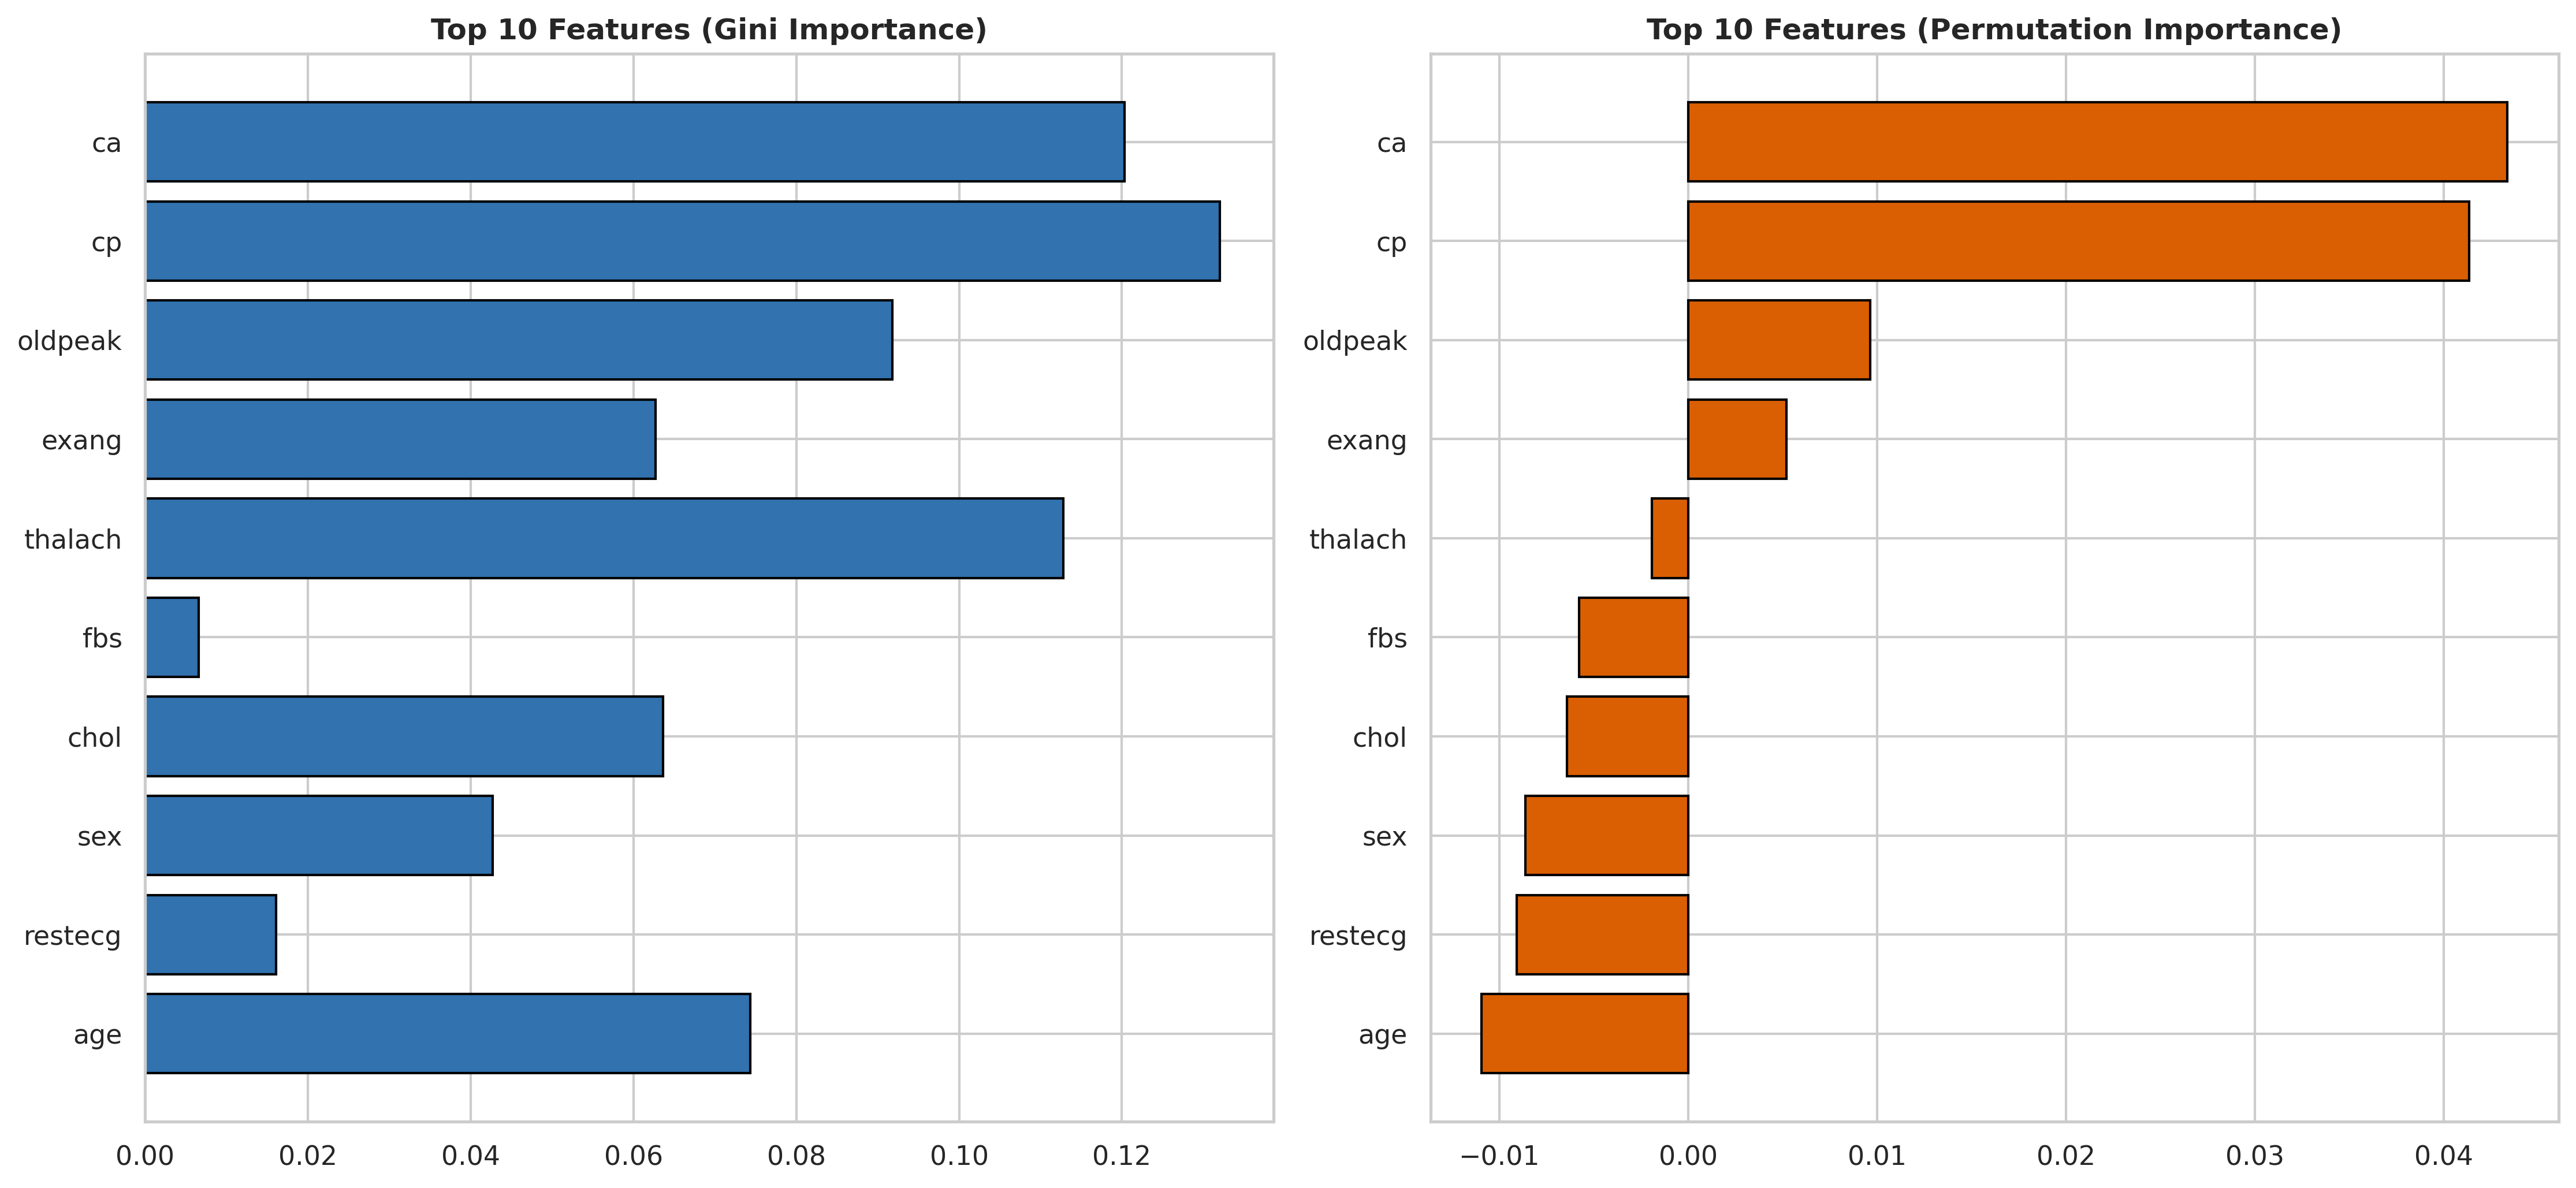

In [18]:
# Compare feature importances using Gini importance and Permutation importance
gini_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
perm_res = permutation_importance(rf_model, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring='balanced_accuracy')
perm_imp = pd.Series(perm_res.importances_mean, index=X.columns)

imp_df = pd.DataFrame({'Gini_Importance': gini_imp, 'Permutation_Importance': perm_imp}).sort_values(by='Permutation_Importance', ascending=False)
imp_df.to_csv('results/heart_disease_feature_importance.csv')

top10 = imp_df.head(10).sort_values(by='Permutation_Importance', ascending=True)
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].barh(top10.index, top10['Gini_Importance'], color='#3172af', edgecolor='black'); ax[0].set_title('Top 10 (Gini Importance)', fontweight='bold')
ax[1].barh(top10.index, top10['Permutation_Importance'], color='#d95f02', edgecolor='black'); ax[1].set_title('Top 10 (Permutation Importance)', fontweight='bold')
plt.tight_layout(); plt.savefig('results/heart_disease_feature_importance.png', dpi=300, bbox_inches='tight'); plt.show()
imp_df.head(10).round(4)


## Model Comparison

Let's put all our evaluation metrics into one clean summary table so we can easily compare our 4 models.

Notice how the **Random Forest** gives us the best overall performance, achieving the highest ROC-AUC score and the lowest Brier error score. It is clearly our winning model!


In [19]:
# Create a summary table comparing all our models across key metrics
records = []
for name, (preds, probs) in models_dict.items():
    records.append({
        'Model Name': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Recall (Sensitivity)': round(recall_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, preds, zero_division=0), 4),
        'ROC-AUC Score': round(roc_auc_score(y_test, probs), 4),
        'Brier Loss Score': round(brier_score_loss(y_test, probs), 4)
    })
comp_df = pd.DataFrame(records)
comp_df.to_csv('results/heart_disease_model_comparison.csv', index=False)

# Save our best model artifact for future use
joblib.dump(rf_model, 'models/heart_disease_best_model.joblib')
joblib.dump(rf_model, 'models/23MID0043_Lab02_HeartDisease_Model.joblib')
comp_df


Saved benchmark table and best model artifacts.


Model Name,Accuracy,Recall (Sensitivity),Precision,F1-Score,ROC-AUC Score,Brier Loss Score
Baseline (Dummy),0.3607,0.2500,0.2800,0.2642,0.3523,0.6393
Basic Decision Tree,0.7869,0.8929,0.7143,0.7937,0.7949,0.2131
Tuned Decision Tree,0.8361,0.7857,0.8462,0.8148,0.8528,0.1566
Random Forest,0.8689,0.9286,0.8125,0.8667,0.9535,0.0974


## Error Analysis

Even our winning model makes a few mistakes on the holdout test set. Why do these errors happen?

By plotting boxplots of the patient measurements for correct predictions versus mistakes, we notice that errors happen in **borderline cases** where a patient's numbers fall in the middle between healthy and diseased averages. In a real hospital, patients with borderline risk scores would be referred to a cardiologist for additional screening.


Test Set Breakdown by Prediction Type:
Result_Type
True Negative (TN)                       27
True Positive (TP)                       26
False Positive (FP - False Alarm)         6
False Negative (FN - Missed Disease!)     2
Saved to results/heart_disease_error_analysis.csv


Result_Type,count
True Negative (TN),27
True Positive (TP),26
False Positive (FP - False Alarm),6
False Negative (FN - Missed Disease!),2


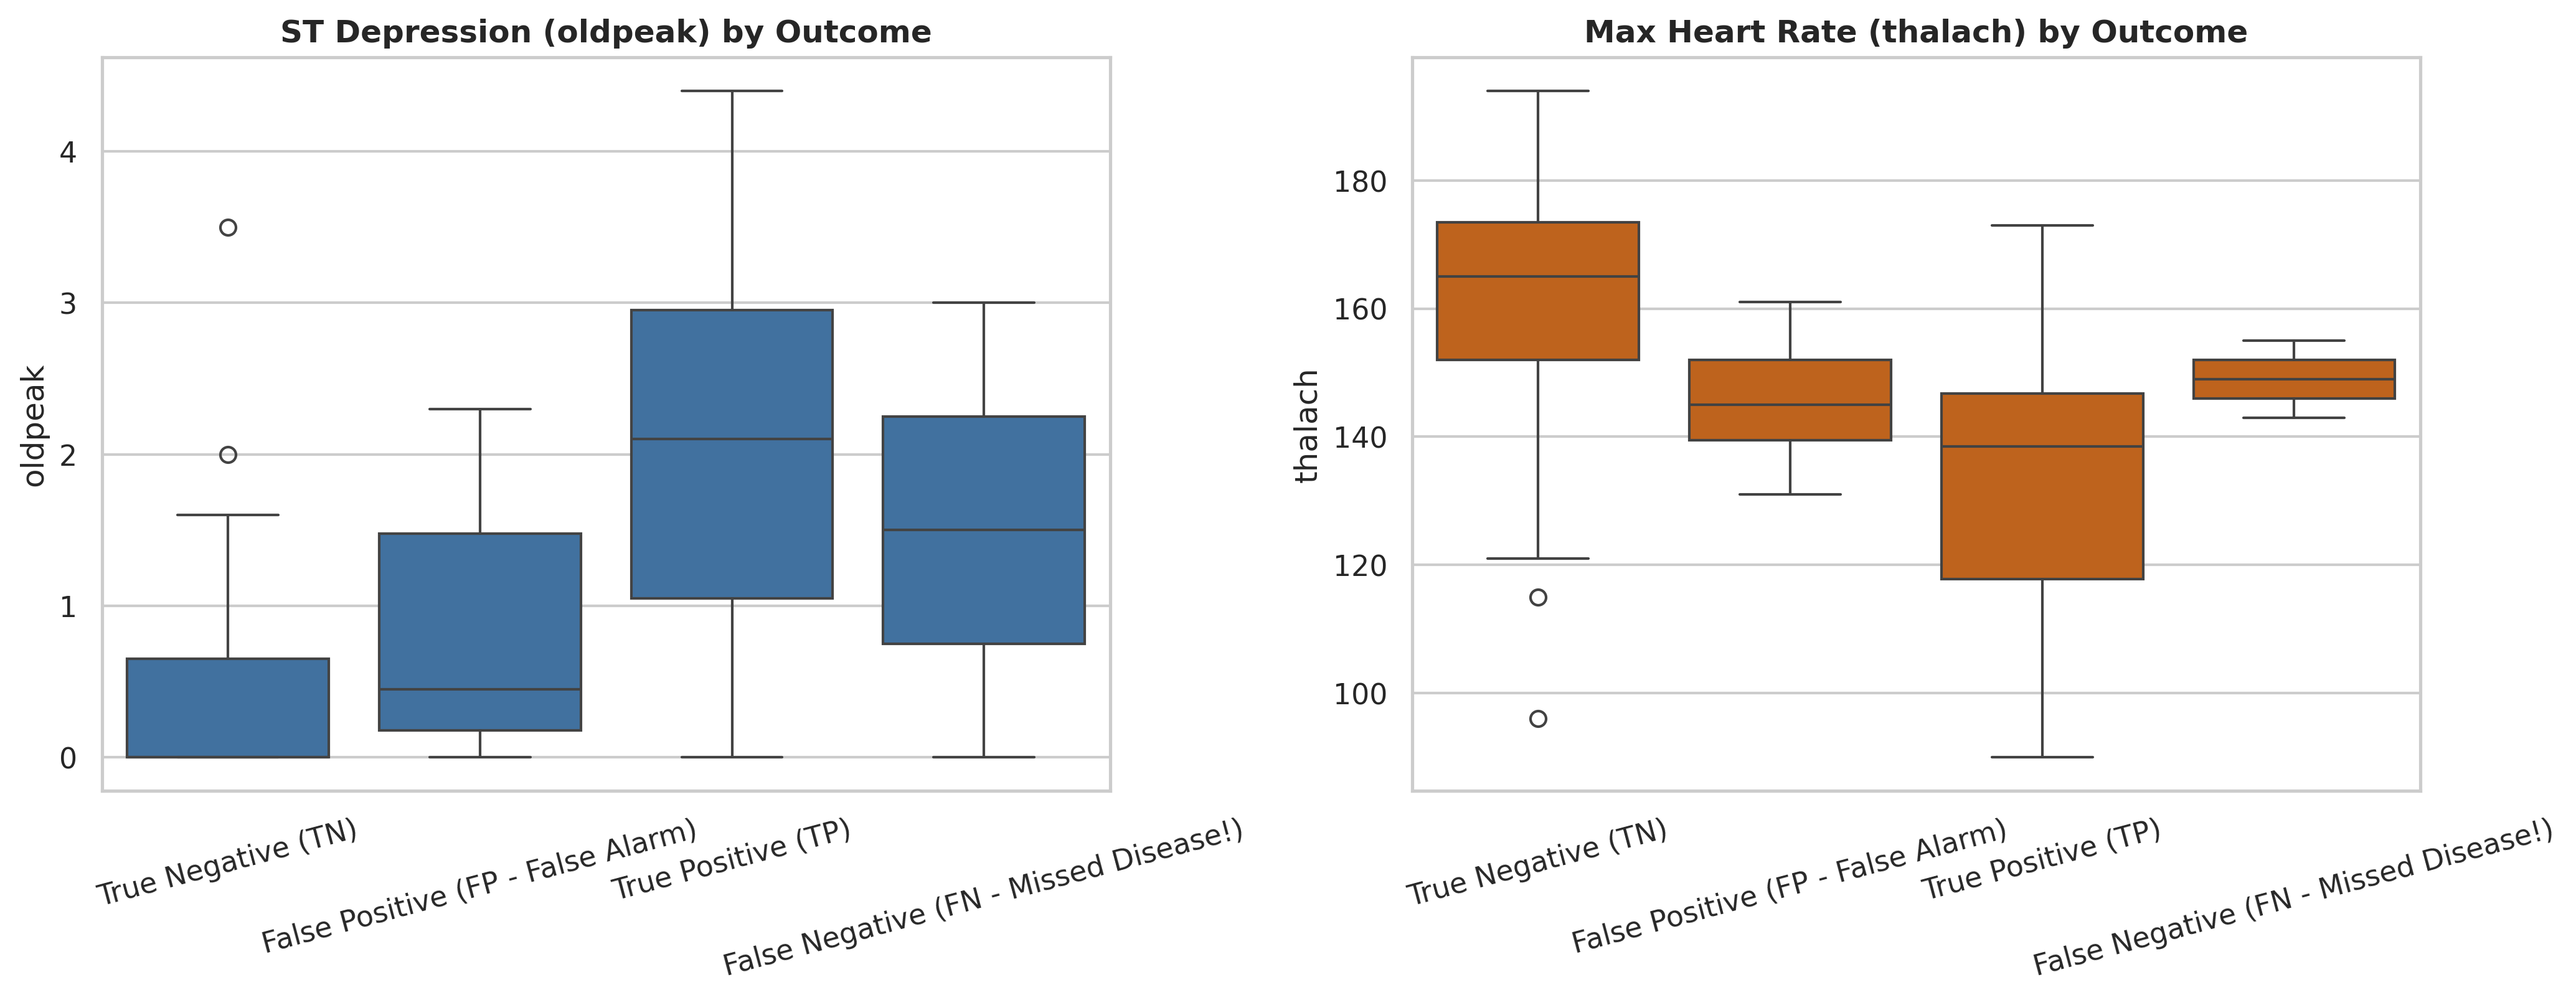

In [20]:
# Examine where our model made mistakes on the test set
test_err_df = X_test.copy()
test_err_df['Actual'] = y_test; test_err_df['Predicted'] = rf_preds

def classify_error(row):
    if row['Actual'] == 1 and row['Predicted'] == 1: return 'True Positive (TP)'
    if row['Actual'] == 0 and row['Predicted'] == 0: return 'True Negative (TN)'
    if row['Actual'] == 1 and row['Predicted'] == 0: return 'False Negative (FN)'
    if row['Actual'] == 0 and row['Predicted'] == 1: return 'False Positive (FP)'

test_err_df['Result_Type'] = test_err_df.apply(classify_error, axis=1)
err_summary = test_err_df['Result_Type'].value_counts()
print("Test Set Breakdown by Prediction Type:\n", err_summary)
err_summary.reset_index().to_csv('results/heart_disease_error_analysis.csv', index=False)

# Plot boxplots to see feature values for correct predictions vs mistakes
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=test_err_df, x='Result_Type', y='oldpeak', ax=axes[0], color='#3172af'); axes[0].set_title('ST Depression by Outcome', fontweight='bold'); axes[0].set_xlabel('')
sns.boxplot(data=test_err_df, x='Result_Type', y='thalach', ax=axes[1], color='#d95f02'); axes[1].set_title('Max Heart Rate by Outcome', fontweight='bold'); axes[1].set_xlabel('')
plt.tight_layout(); plt.savefig('results/heart_disease_error_analysis_boxplots.png', dpi=300, bbox_inches='tight'); plt.show()


## Conclusion

In this lab experiment, we learned how to apply decision trees and ensemble methods to clinical cardiology data:
1. **Decision Trees can easily overfit**: We saw that a basic, unconstrained decision tree memorized 100% of the training data but made more mistakes on new test patients.
2. **Pruning creates simple, reliable rules**: By tuning hyperparameters with GridSearchCV, we pruned our tree to create a simpler, cleaner model that generalized much better.
3. **Random Forests provide superior stability**: Combining 200 trees in a Random Forest gave us the highest accuracy and best probability estimates.
4. **Clinical Interpretation**: Our feature importance analysis confirmed that stress test results (`thal`), blood vessel counts (`ca`), and chest pain type (`cp`) are the most important indicators of cardiac health.


## References

1. **UCI Machine Learning Repository**: Heart Disease (Cleveland) Clinical Dataset.
2. **Breiman, L., et al.** (1984). *Classification and Regression Trees*. Wadsworth & Brooks/Cole.
3. **Breiman, L.** (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
4. **Pedregosa, F., et al.** (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
